In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import random

# Although not strictly used in this initial setup, these are common ML libraries.
# Specific N-BEATS implementation libraries (e.g., darts, neuralforecast) can be added later.
# For example, you might add: `!pip install neuralforecast` or `!pip install darts`
import sklearn # Placeholder for scikit-learn
# import catboost # Placeholder for catboost
# import torch # Placeholder for pytorch

# Set random seed for reproducibility
RANDOM_SEED = 42
pd.set_option('display.max_columns', None)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Random seed set to {RANDOM_SEED}")

Random seed set to 42


In [ ]:
# Adjust these paths if your files are located differently
df_final = pd.read_csv('/content/drive/My Drive/df_daily_final.csv') # Assuming df_final.csv exists
df_final_eval = pd.read_csv('/content/drive/My Drive/df_daily_eval_final.csv')

print("df_final head:")
display(df_final.head())

print("\ndf_final_eval head:")
display(df_final_eval.head())

df_final head:


,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,sale_amount_log,lag_1_log,lag_7_log,lag_14_log,roll_mean_7_log,roll_mean_14_log,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,month_sin,month_cos,week_of_year_sin,week_of_year_cos,quarter_sin,quarter_cos,day_of_year_sin,day_of_year_cos,lag_1_discount,rolling_std_7_log,rolling_std_14_log,cv_7_log,cv_14_log,binary_stockout,is_weekend,stock_recovery,sale_stock_ratio_previous_day,prev_sale_stock_interaction,lag_1_roll_14_interaction,prev_day_hourly_sales_mean_active,prev_day_hourly_stock_active_ratio_active,prev_day_hourly_stockout_ratio_active,roll_mean_28_log,days_since_last_stockout,days_since_last_promo
0,64,2,29,78,82,4,2024-03-28,-0.685466,0.426733,0,0,0.158230,-1.886704,0.051583,1.433120,0.262364,-1.397572,-1.2644,-1.13205,-1.487527,-1.33055,0,0,0.632171,-1.271319,1.398069,2.852933,1.167872,2.013777,4.636809,4.636809,1.107003,1.983991,-5.741037,-1.510632,-1.438692,-1.305944,-1.262748,0,0,0,-0.782931,-0.565709,-0.568525,-0.729927,-2.458888,-0.837806,-1.057567,-0.515390,-0.434314
1,64,2,29,78,82,4,2024-03-29,0.147025,0.426733,0,0,0.600596,-2.343486,0.568683,0.686767,0.788457,-0.734608,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-0.601373,-1.271319,1.398069,2.852933,1.167872,2.013777,4.636809,4.636809,1.110165,1.931235,0.405520,-1.510632,-1.438692,-1.305944,-1.262748,1,0,0,-0.138836,-0.565709,-0.568525,-0.469177,0.848809,-0.837806,-1.057567,-0.515390,-0.434314
2,64,2,29,78,82,4,2024-03-30,0.147025,0.426733,1,0,-0.246555,-1.916280,0.325342,0.293950,1.526056,0.594768,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-1.370475,-0.316610,1.398069,2.852933,1.167872,2.013777,4.636809,4.636809,1.112273,1.878440,0.405520,-1.510632,-1.438692,-1.305944,-1.262748,1,1,0,-0.782930,0.806614,-0.568525,0.313074,-0.096248,0.137217,-1.057567,-0.515390,-0.434314
3,64,2,29,78,82,4,2024-03-31,-0.685466,0.077504,1,0,-0.404629,-1.975431,0.433976,0.608204,1.916923,2.458594,-1.2644,-1.13205,-1.487527,-1.33055,0,1,-1.095986,0.873893,1.398069,2.852933,1.167872,2.013777,4.636809,4.636809,1.113327,1.825622,0.405520,-1.510632,-1.438692,-1.305944,-1.262748,0,1,1,-0.782930,2.090418,-0.568525,2.399077,-0.253757,0.299721,-1.057567,-0.515390,-0.434314
4,64,2,29,78,82,4,2024-04-01,-0.685466,0.426733,0,0,-0.012217,-2.169317,0.340551,1.511684,0.262364,3.446267,-1.2644,-1.13205,-1.487527,-1.33055,1,0,0.015399,1.403717,1.019412,0.932392,1.143649,1.626174,-0.215666,-0.215666,1.113327,1.772796,0.126994,-1.510632,-1.438692,-1.305944,-1.262748,0,0,0,3.923042,-0.565709,-0.568525,4.311247,0.848809,-0.837806,-1.057567,-0.289036,-0.434314



df_final_eval head:


,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,sale_amount_log,lag_1_log,lag_7_log,lag_14_log,roll_mean_7_log,roll_mean_14_log,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,month_sin,month_cos,week_of_year_sin,week_of_year_cos,quarter_sin,quarter_cos,day_of_year_sin,day_of_year_cos,lag_1_discount,rolling_std_7_log,rolling_std_14_log,cv_7_log,cv_14_log,binary_stockout,is_weekend,stock_recovery,sale_stock_ratio_previous_day,prev_sale_stock_interaction,lag_1_roll_14_interaction,prev_day_hourly_sales_mean_active,prev_day_hourly_stock_active_ratio_active,prev_day_hourly_stockout_ratio_active,roll_mean_28_log,days_since_last_stockout,days_since_last_promo
0,64,2,29,78,82,4,2024-06-26,0.147025,0.180685,0,0,2.945008,1.816846,0.327515,-0.648813,0.693147,-1.397572,-1.2644,-1.13205,-1.487527,-1.33055,0,0,1.401273,-0.316610,-1.428265,-0.988149,-2.15434,-1.201869,-0.215666,-0.215666,-2.157389,-1.266655,-5.741037,-1.510632,-1.438692,-1.305944,-1.262748,1,0,0,-0.782931,-0.565709,-0.568525,-0.729927,-1.828851,1.924760,-1.057567,-0.515390,-0.434314
1,64,2,29,78,82,4,2024-06-27,-0.477343,0.656907,0,0,0.433704,2.247338,0.234089,-0.648813,0.470004,0.353930,-1.2644,-1.13205,-1.487527,-1.33055,0,0,0.632171,-1.271319,-1.428265,-0.988149,-2.15434,-1.201869,-0.215666,-0.215666,-2.218621,-1.270732,0.209286,-1.510632,-1.438692,-1.305944,-1.262748,1,0,0,-0.782930,0.640725,-0.568525,0.139241,-0.096248,0.137217,-1.057567,-0.515390,-0.434314
2,64,2,29,78,82,4,2024-06-28,-0.685466,0.180685,0,0,0.151652,2.109318,-0.100505,-1.159475,0.741937,-0.209928,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-0.601373,-1.271319,-1.428265,-0.988149,-2.15434,-1.201869,-0.215666,-0.215666,-2.279926,-1.273904,0.589093,-1.510632,-1.438692,-1.305944,-1.262748,0,0,1,-0.782930,-0.361197,-0.568525,-0.208426,0.533790,-0.512798,-1.057567,-0.515390,-0.434314
3,64,2,29,78,82,4,2024-06-29,-0.477343,0.006070,1,0,-0.480467,2.730410,0.405731,-0.373840,0.875469,0.477217,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-1.370475,-0.316610,-1.428265,-0.988149,-2.15434,-1.201869,-0.215666,-0.215666,-2.341285,-1.276170,0.209286,-1.510632,-1.438692,-1.305944,-1.262748,1,1,0,1.038497,-0.565709,-0.568525,0.226158,0.848809,-0.837806,-1.057567,-0.289036,-0.434314
4,64,2,29,78,82,4,2024-06-30,0.771394,-0.009804,1,0,0.310793,2.194759,-0.495934,0.254668,1.547563,0.814635,-1.2644,-1.13205,-1.487527,-1.33055,0,1,-1.095986,0.873893,-1.428265,-0.988149,-2.15434,-1.201869,-0.215666,-0.215666,-2.402681,-1.277531,0.070023,-1.510632,-1.438692,-1.305944,-1.262748,1,1,0,-0.782929,-0.184767,-0.568525,0.486908,0.691299,-0.675302,-1.057567,-0.515390,-0.434314


In [ ]:
df_final['dt'] = pd.to_datetime(df_final['dt'])
df_final_eval['dt'] = pd.to_datetime(df_final_eval['dt'])

print("Converted 'dt' column to datetime objects in df_final and df_final_eval.")
print("df_final['dt'] dtype:", df_final['dt'].dtype)
print("df_final_eval['dt'] dtype:", df_final_eval['dt'].dtype)

Converted 'dt' column to datetime objects in df_final and df_final_eval.
df_final['dt'] dtype: datetime64[ns]
df_final_eval['dt'] dtype: datetime64[ns]


Now, let's check the stockout counts for both `df_final` and `df_final_eval`.

In [ ]:
print("Counts of binary_stockout in df_final:")
stockout_counts_final = df_final['binary_stockout'].value_counts()
print(stockout_counts_final)
print("Percentages of binary_stockout in df_final:")
print(df_final['binary_stockout'].value_counts(normalize=True) * 100)

print("\nCounts of binary_stockout in df_final_eval:")
stockout_counts_eval = df_final_eval['binary_stockout'].value_counts()
print(stockout_counts_eval)
print("Percentages of binary_stockout in df_final_eval:")
print(df_final_eval['binary_stockout'].value_counts(normalize=True) * 100)

Counts of binary_stockout in df_final:
binary_stockout
0    254313
1    206217
Name: count, dtype: int64
Percentages of binary_stockout in df_final:
binary_stockout
0    55.22181
1    44.77819
Name: proportion, dtype: float64

Counts of binary_stockout in df_final_eval:
binary_stockout
0    21645
1    14174
Name: count, dtype: int64
Percentages of binary_stockout in df_final_eval:
binary_stockout
0    60.428823
1    39.571177
Name: proportion, dtype: float64


In [ ]:
columns_to_drop = [
    'day_of_year_sin', 'day_of_year_cos', 'quarter_cos',
    'rolling_std_7_log', 'rolling_std_14_log','lag_1_discount',
    'prev_day_hourly_stock_active_ratio_active','week_of_year_sin',
    'week_of_year_cos','quarter_sin','days_since_last_promo',
    'stock_recovery','is_weekend','cv_14_log','roll_mean_28_log',
    'month_cos','month_sin'
]

# Drop the specified columns from df_final
df_final = df_final.drop(columns=columns_to_drop, errors='ignore')
print("df_final after dropping columns:")
display(df_final.head())
print(f"New shape of df_final: {df_final.shape}")

# Drop the specified columns from df_final_eval
df_final_eval = df_final_eval.drop(columns=columns_to_drop, errors='ignore')
print("\ndf_final_eval after dropping columns:")
display(df_final_eval.head())
print(f"New shape of df_final_eval: {df_final_eval.shape}")

df_final after dropping columns:


,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,sale_amount_log,lag_1_log,lag_7_log,lag_14_log,roll_mean_7_log,roll_mean_14_log,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,cv_7_log,binary_stockout,sale_stock_ratio_previous_day,prev_sale_stock_interaction,lag_1_roll_14_interaction,prev_day_hourly_sales_mean_active,prev_day_hourly_stockout_ratio_active,days_since_last_stockout
0,64,2,29,78,82,4,2024-03-28,-0.685466,0.426733,0,0,0.158230,-1.886704,0.051583,1.433120,0.262364,-1.397572,-1.2644,-1.13205,-1.487527,-1.33055,0,0,0.632171,-1.271319,-1.305944,0,-0.782931,-0.565709,-0.568525,-0.729927,-0.837806,-0.515390
1,64,2,29,78,82,4,2024-03-29,0.147025,0.426733,0,0,0.600596,-2.343486,0.568683,0.686767,0.788457,-0.734608,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-0.601373,-1.271319,-1.305944,1,-0.138836,-0.565709,-0.568525,-0.469177,-0.837806,-0.515390
2,64,2,29,78,82,4,2024-03-30,0.147025,0.426733,1,0,-0.246555,-1.916280,0.325342,0.293950,1.526056,0.594768,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-1.370475,-0.316610,-1.305944,1,-0.782930,0.806614,-0.568525,0.313074,0.137217,-0.515390
3,64,2,29,78,82,4,2024-03-31,-0.685466,0.077504,1,0,-0.404629,-1.975431,0.433976,0.608204,1.916923,2.458594,-1.2644,-1.13205,-1.487527,-1.33055,0,1,-1.095986,0.873893,-1.305944,0,-0.782930,2.090418,-0.568525,2.399077,0.299721,-0.515390
4,64,2,29,78,82,4,2024-04-01,-0.685466,0.426733,0,0,-0.012217,-2.169317,0.340551,1.511684,0.262364,3.446267,-1.2644,-1.13205,-1.487527,-1.33055,1,0,0.015399,1.403717,-1.305944,0,3.923042,-0.565709,-0.568525,4.311247,-0.837806,-0.289036


New shape of df_final: (460530, 33)

df_final_eval after dropping columns:


,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,sale_amount_log,lag_1_log,lag_7_log,lag_14_log,roll_mean_7_log,roll_mean_14_log,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,cv_7_log,binary_stockout,sale_stock_ratio_previous_day,prev_sale_stock_interaction,lag_1_roll_14_interaction,prev_day_hourly_sales_mean_active,prev_day_hourly_stockout_ratio_active,days_since_last_stockout
0,64,2,29,78,82,4,2024-06-26,0.147025,0.180685,0,0,2.945008,1.816846,0.327515,-0.648813,0.693147,-1.397572,-1.2644,-1.13205,-1.487527,-1.33055,0,0,1.401273,-0.316610,-1.305944,1,-0.782931,-0.565709,-0.568525,-0.729927,1.924760,-0.515390
1,64,2,29,78,82,4,2024-06-27,-0.477343,0.656907,0,0,0.433704,2.247338,0.234089,-0.648813,0.470004,0.353930,-1.2644,-1.13205,-1.487527,-1.33055,0,0,0.632171,-1.271319,-1.305944,1,-0.782930,0.640725,-0.568525,0.139241,0.137217,-0.515390
2,64,2,29,78,82,4,2024-06-28,-0.685466,0.180685,0,0,0.151652,2.109318,-0.100505,-1.159475,0.741937,-0.209928,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-0.601373,-1.271319,-1.305944,0,-0.782930,-0.361197,-0.568525,-0.208426,-0.512798,-0.515390
3,64,2,29,78,82,4,2024-06-29,-0.477343,0.006070,1,0,-0.480467,2.730410,0.405731,-0.373840,0.875469,0.477217,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-1.370475,-0.316610,-1.305944,1,1.038497,-0.565709,-0.568525,0.226158,-0.837806,-0.289036
4,64,2,29,78,82,4,2024-06-30,0.771394,-0.009804,1,0,0.310793,2.194759,-0.495934,0.254668,1.547563,0.814635,-1.2644,-1.13205,-1.487527,-1.33055,0,1,-1.095986,0.873893,-1.305944,1,-0.782929,-0.184767,-0.568525,0.486908,-0.675302,-0.515390


New shape of df_final_eval: (35819, 33)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns (excluding 'dt' and 'sale_amount_log')
categorical_cols = [
    'store_id', 'management_group_id', 'first_category_id',
    'second_category_id', 'third_category_id', 'product_id',
    'holiday_flag', 'activity_flag',
     'binary_stockout','is_month_start','is_month_end'
]

# Apply Label Encoding to categorical features in both dataframes
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on df_final and transform both
    df_final[col] = le.fit_transform(df_final[col])
    df_final_eval[col] = le.transform(df_final_eval[col]) # Use transform for eval set to avoid new categories

print("Label Encoding applied to categorical columns in df_final and df_final_eval.")

# Define target variables
y_train = df_final['sale_amount_log']
y_test = df_final_eval['sale_amount_log']

# Define feature sets by dropping 'dt' and 'sale_amount_log'
X_train = df_final.drop(columns=['dt', 'sale_amount_log'])
X_test = df_final_eval.drop(columns=['dt', 'sale_amount_log'])

print("Target variables (y_train, y_test) and feature sets (X_train, X_test) created.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Label Encoding applied to categorical columns in df_final and df_final_eval.
Target variables (y_train, y_test) and feature sets (X_train, X_test) created.
X_train shape: (460530, 31), y_train shape: (460530,)
X_test shape: (35819, 31), y_test shape: (35819,)


In [ ]:
# 1. Save true target before masking
df_final['sale_amount_log_true'] = df_final['sale_amount_log']
df_final['binary_stockout_masked'] = df_final['binary_stockout']

# 2. Create masked version of sales for training the imputer
df_final['sale_amount_log_masked'] = df_final['sale_amount_log_true']

# 3. Select uncensored rows (normal demand)
uncensored_sales_rows = df_final[
    (df_final['binary_stockout'] == 0) & (df_final['sale_amount_log_true'] > 0)
]

# 4. Sample 15% artificial stockouts per store-product
sample_fraction = 0.15
RANDOM_SEED = 42

artificial_stockout_indices = (
    uncensored_sales_rows
    .groupby(['store_id', 'product_id'], group_keys=False)
    .apply(lambda x: x.sample(frac=sample_fraction, random_state=RANDOM_SEED))
    .index
)

# 5. Apply masking
df_final.loc[artificial_stockout_indices, 'sale_amount_log_masked'] = 0
df_final.loc[artificial_stockout_indices, 'binary_stockout_masked'] = 1

print("Artificial stockouts created correctly.")
print(df_final[['sale_amount_log_true', 'sale_amount_log_masked', 'binary_stockout_masked']].head())
print(df_final['binary_stockout_masked'].value_counts(normalize=True) * 100)


Artificial stockouts created correctly.
   sale_amount_log_true  sale_amount_log_masked  binary_stockout_masked
0              0.262364                0.262364                       0
1              0.788457                0.788457                       1
2              1.526056                1.526056                       1
3              1.916923                1.916923                       0
4              0.262364                0.262364                       0
binary_stockout_masked
1    52.91816
0    47.08184
Name: proportion, dtype: float64


/tmp/ipython-input-158239066.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sample_fraction, random_state=RANDOM_SEED))


## Identify Imputer Features

### Subtask:
Select the specified covariate columns from `df_final` to form the feature set for the CatBoost imputer.


In [ ]:
imputer_features = [
    'discount',
    'holiday_flag',
    'activity_flag',
    'precpt',
    'avg_temperature',
    'avg_humidity',
    'avg_wind_level',
    'lag_1_log',
    'lag_7_log',
    'lag_14_log',
    'days_since_last_stockout',
    'sale_stock_ratio_previous_day',
    'stock_hour6_22_cnt',
    'product_id',
    'store_id',
    'management_group_id',
    'first_category_id',
    'second_category_id',
    'third_category_id',
    'prev_sale_stock_interaction',
    'lag_1_roll_14_interaction',
    'prev_day_hourly_sales_mean_active',
    'prev_day_hourly_stockout_ratio_active',
    'cv_7_log',
    'is_month_start',
    'is_month_end',
    'day_of_week_sin',
    'day_of_week_cos',
    'roll_mean_7_log',
    'roll_mean_14_log'
]


print("Imputer features list created.")
print(f"Number of imputer features: {len(imputer_features)}")

Imputer features list created.
Number of imputer features: 30


In [ ]:
df_final['imputer_target'] = df_final['sale_amount_log_true'].copy()
# Set the target to NaN where binary_stockout_masked is 0 (i.e., observed demand points)
df_final.loc[df_final['binary_stockout_masked'] == 0, 'imputer_target'] = np.nan

print("Imputer target column 'imputer_target' created in df_final.")
print("Number of NaNs in imputer_target: ", df_final['imputer_target'].isnull().sum())
print(df_final[['sale_amount_log_true', 'binary_stockout_masked', 'imputer_target']].head())

Imputer target column 'imputer_target' created in df_final.
Number of NaNs in imputer_target:  216826
   sale_amount_log_true  binary_stockout_masked  imputer_target
0              0.262364                       0             NaN
1              0.788457                       1        0.788457
2              1.526056                       1        1.526056
3              1.916923                       0             NaN
4              0.262364                       0             NaN


In [ ]:
df_imputer = df_final[imputer_features + ['dt', 'binary_stockout_masked', 'imputer_target']].copy()

print("df_imputer created with selected features, target, dt, and binary_stockout_masked.")
print(f"Shape of df_imputer: {df_imputer.shape}")
display(df_imputer.head())

df_imputer created with selected features, target, dt, and binary_stockout_masked.
Shape of df_imputer: (460530, 33)


,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,lag_1_log,lag_7_log,lag_14_log,days_since_last_stockout,sale_stock_ratio_previous_day,stock_hour6_22_cnt,product_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,prev_sale_stock_interaction,lag_1_roll_14_interaction,prev_day_hourly_sales_mean_active,prev_day_hourly_stockout_ratio_active,cv_7_log,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,roll_mean_7_log,roll_mean_14_log,dt,binary_stockout_masked,imputer_target
0,0.426733,0,0,0.158230,-1.886704,0.051583,1.433120,-1.397572,-1.2644,-1.13205,-0.515390,-0.782931,-0.685466,1,0,2,24,57,51,-0.565709,-0.568525,-0.729927,-0.837806,-1.305944,0,0,0.632171,-1.271319,-1.487527,-1.33055,2024-03-28,0,NaN
1,0.426733,0,0,0.600596,-2.343486,0.568683,0.686767,-0.734608,-1.2644,-1.13205,-0.515390,-0.138836,0.147025,1,0,2,24,57,51,-0.565709,-0.568525,-0.469177,-0.837806,-1.305944,0,0,-0.601373,-1.271319,-1.487527,-1.33055,2024-03-29,1,0.788457
2,0.426733,1,0,-0.246555,-1.916280,0.325342,0.293950,0.594768,-1.2644,-1.13205,-0.515390,-0.782930,0.147025,1,0,2,24,57,51,0.806614,-0.568525,0.313074,0.137217,-1.305944,0,0,-1.370475,-0.316610,-1.487527,-1.33055,2024-03-30,1,1.526056
3,0.077504,1,0,-0.404629,-1.975431,0.433976,0.608204,2.458594,-1.2644,-1.13205,-0.515390,-0.782930,-0.685466,1,0,2,24,57,51,2.090418,-0.568525,2.399077,0.299721,-1.305944,0,1,-1.095986,0.873893,-1.487527,-1.33055,2024-03-31,0,NaN
4,0.426733,0,0,-0.012217,-2.169317,0.340551,1.511684,3.446267,-1.2644,-1.13205,-0.289036,3.923042,-0.685466,1,0,2,24,57,51,-0.565709,-0.568525,4.311247,-0.837806,-1.305944,1,0,0.015399,1.403717,-1.487527,-1.33055,2024-04-01,0,NaN


## Split Imputer Training and Validation Sets

### Subtask:
Split df_imputer into training and validation sets using an 80/20 time-aware split based on 'dt', prioritizing more recent masked rows for validation.


In [ ]:
# Step 1: Select ONLY rows that have a label (i.e., masked artificial stockouts)
df_labeled = df_imputer[df_imputer['imputer_target'].notnull()].copy()

print("Number of labeled (masked) rows:", len(df_labeled))

# Step 2: Sort by dt (time-aware split)
df_labeled = df_labeled.sort_values(by='dt').reset_index(drop=True)

# Step 3: 80/20 time split ONLY on labeled rows
split_index = int(len(df_labeled) * 0.8)

df_imputer_train = df_labeled.iloc[:split_index].copy()
df_imputer_val   = df_labeled.iloc[split_index:].copy()

print("df_imputer_train shape:", df_imputer_train.shape)
print("df_imputer_val shape:", df_imputer_val.shape)
print("Total masked rows used for imputer:", len(df_labeled))


Number of labeled (masked) rows: 243704
df_imputer_train shape: (194963, 33)
df_imputer_val shape: (48741, 33)
Total masked rows used for imputer: 243704


## Identify CatBoost Categorical Features

### Subtask:
Identify which columns in the `imputer_features` list are categorical and get their indices. This is crucial for CatBoost to handle them correctly. I will use the `categorical_cols` defined earlier, along with `product_id` and `store_id`, to determine these.


In [ ]:
cat_features_names = [col for col in imputer_features if col in categorical_cols]

cat_features_indices = [imputer_features.index(col) for col in cat_features_names]

print("Identified categorical feature names for CatBoost:")
print(cat_features_names)
print("\nIndices of categorical features in imputer_features:")
print(cat_features_indices)

Identified categorical feature names for CatBoost:
['holiday_flag', 'activity_flag', 'product_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'is_month_start', 'is_month_end']

Indices of categorical features in imputer_features:
[1, 2, 13, 14, 15, 16, 17, 18, 24, 25]


## Prepare Training Data for CatBoost

### Subtask:
Extract features (X) and target (y) from `df_imputer_train` and `df_imputer_val`. For training, filter `df_imputer_train` to include only rows where `imputer_target` is not NaN, as CatBoost will learn only from these labeled instances.


In [ ]:
X_train_imputer = df_imputer_train.drop(columns=['dt', 'binary_stockout_masked', 'imputer_target'])
y_train_imputer = df_imputer_train['imputer_target']

X_val_imputer = df_imputer_val.drop(columns=['dt', 'binary_stockout_masked', 'imputer_target'])
y_val_imputer = df_imputer_val['imputer_target']

print("Imputer training and validation sets (X and y) created.")
print(f"X_train_imputer shape: {X_train_imputer.shape}, y_train_imputer shape: {y_train_imputer.shape}")
print(f"X_val_imputer shape: {X_val_imputer.shape}, y_val_imputer shape: {y_val_imputer.shape}")

Imputer training and validation sets (X and y) created.
X_train_imputer shape: (194963, 30), y_train_imputer shape: (194963,)
X_val_imputer shape: (48741, 30), y_val_imputer shape: (48741,)


## Define Custom WAPE Metric

### Subtask:
Implement a Python function to calculate the Weighted Absolute Percentage Error (WAPE), as this is a custom metric and not directly available in CatBoost's built-in metrics. This will be used for validation monitoring.


In [ ]:
import numpy as np

def wape_metric(y_true, y_pred):
    """
    Calculates the Weighted Absolute Percentage Error (WAPE).

    Args:
        y_true (array-like): True values.
        y_pred (array-like): Predicted values.

    Returns:
        float: The WAPE value as a percentage.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Calculate absolute differences
    abs_diff = np.abs(y_true - y_pred)

    # Sum of absolute differences
    sum_abs_diff = np.sum(abs_diff)

    # Sum of true values
    sum_y_true = np.sum(y_true)

    # Handle potential division by zero
    if sum_y_true == 0:
        return 0.0 # Or np.nan, depending on desired behavior for all zeros

    wape = (sum_abs_diff / sum_y_true) * 100
    return wape

print("WAPE metric function 'wape_metric' defined.")

WAPE metric function 'wape_metric' defined.


## Initialize and Train CatBoost Imputer

### Subtask:
Initialize the `CatBoostRegressor` model with the specified hyperparameters and train it using the prepared training data, monitoring performance on the validation set.


In [ ]:
import sys
!{sys.executable} -m pip install catboost

from catboost import CatBoostRegressor, Pool

# Initialize CatBoostRegressor model
cb_imputer = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    random_seed=RANDOM_SEED,
    loss_function='MAE',
    eval_metric='MAE',
    verbose=100,
    early_stopping_rounds=50
)

print("CatBoostRegressor model initialized. Starting training...")

# Create Pool datasets for CatBoost (recommended)
train_pool = Pool(
    data=X_train_imputer,
    label=y_train_imputer,
    cat_features=cat_features_indices
)

val_pool = Pool(
    data=X_val_imputer,
    label=y_val_imputer,
    cat_features=cat_features_indices
)

print("Training and validation Pool objects created.")

# Train the model using Pool objects
cb_imputer.fit(
    train_pool,
    eval_set=val_pool,
    verbose=100
)

print("CatBoostRegressor model training completed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00
CatBoostRegressor model initialized. Starting training...
Training and validation Pool objects created.
0:	learn: 0.2721221	test: 0.3029358	best: 0.3029358 (0)	total: 452ms	remaining: 7m 31s
100:	learn: 0.1232081	test: 0.1433247	best: 0.1433247 (100)	total: 30.9s	remaining: 4m 34s
200:	learn: 0.1161200	test: 0.1394425	best: 0.1394398 (198)	total: 1m 2s	remaining: 4m 9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.139238938
bestIteration = 205

Shrink model to first 206 iterations.
CatBoostRegressor model training completed.


## Evaluate CatBoost Imputer on Validation Set

### Subtask:
Use the trained CatBoost model to make predictions on the `df_imputer_val` set. Calculate and print the Mean Absolute Error (MAE) and the custom WAPE using the `imputer_target` (only where it's not NaN) and predictions for the validation set.


In [ ]:
from sklearn.metrics import mean_absolute_error

# 1. Make predictions on the validation set
y_pred_imputer = cb_imputer.predict(X_val_imputer)

# 2. Calculate and print Mean Absolute Error (MAE)
mae = mean_absolute_error(y_val_imputer, y_pred_imputer)
print(f"Mean Absolute Error (MAE) on validation set: {mae:.4f}")

# 3. Calculate and print Weighted Absolute Percentage Error (WAPE)
wape = wape_metric(y_val_imputer, y_pred_imputer)
print(f"Weighted Absolute Percentage Error (WAPE) on validation set: {wape:.2f}%")


Mean Absolute Error (MAE) on validation set: 0.1392
Weighted Absolute Percentage Error (WAPE) on validation set: 22.35%


## Save CatBoost Imputer Model

### Subtask:
Save the trained CatBoostRegressor model to a file, making it available for future use or deployment.


**Reasoning**:
I need to save the trained CatBoostRegressor model to a file using its `save_model` method for future use.



In [ ]:
cb_imputer.save_model('catboost_imputer_model.cbm')
print("CatBoost imputer model saved as 'catboost_imputer_model.cbm'")

CatBoost imputer model saved as 'catboost_imputer_model.cbm'


##5

In [ ]:
# ---------- Imports ----------
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

# ---------- Helper metrics (operate on ORIGINAL scale) ----------
def wape_metric(y_true, y_pred):
    """Weighted Absolute Percentage Error in percent, safe for zero-sum."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return np.nan
    return (np.sum(np.abs(y_pred - y_true)) / denom) * 100.0

def wpe_metric_bias(y_true, y_pred):
    """
    Weighted Percentage Error (bias) in percent.
    Returns positive => overestimation, negative => underestimation.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(y_true)
    if denom == 0:
        return np.nan
    return (np.sum(y_pred - y_true) / denom) * 100.0

def rmse_metric(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

# ---------- Prepare evaluation arrays (ensure alignment) ----------
# y_val_imputer and y_pred_imputer must be numpy arrays or pandas Series.
# These are the masked validation targets and predictions produced by the imputer.
y_val_imputer = np.asarray(y_val_imputer)     # likely log-scale
y_pred_imputer = np.asarray(y_pred_imputer)   # likely log-scale

# Convert back to original scale if your model predicted log-values
# (Assuming sale_amount_log = np.log1p(original_sales))
y_val_orig = np.expm1(y_val_imputer)
y_pred_orig = np.expm1(y_pred_imputer)

# ---------- Overall metrics ----------
wape_overall = wape_metric(y_val_orig, y_pred_orig)
wpe_bias_overall = wpe_metric_bias(y_val_orig, y_pred_orig)
mae_overall = mean_absolute_error(y_val_orig, y_pred_orig)
rmse_overall = rmse_metric(y_val_orig, y_pred_orig)

print(f"Overall WAPE on validation set: {wape_overall:.2f}%")
print(f"Overall WPE (Bias) on validation set: {wpe_bias_overall:.2f}%")
print(f"Overall MAE on validation set: {mae_overall:.4f}")
print(f"Overall RMSE on validation set: {rmse_overall:.4f}")

# ---------- Build df_eval_results with aligned indices ----------
# Ensure df_imputer_val aligns with y_val_imputer -> reset indices
df_eval_results = pd.DataFrame({
    'y_true_log': y_val_imputer,
    'y_pred_log': y_pred_imputer,
})
df_eval_results = df_eval_results.reset_index(drop=True)

# Select features from df_imputer_val and align
feature_cols = ['dt', 'store_id', 'product_id', 'holiday_flag', 'activity_flag', 'day_of_week_sin', 'day_of_week_cos']
selected_features = df_imputer_val[feature_cols].reset_index(drop=True)
df_eval_results = pd.concat([df_eval_results, selected_features], axis=1)

# Add original-scale columns
df_eval_results['y_true'] = np.expm1(df_eval_results['y_true_log'])
df_eval_results['y_pred'] = np.expm1(df_eval_results['y_pred_log'])

print("df_eval_results created. Shape:", df_eval_results.shape)
display(df_eval_results.head())

# ---------- Sale-level bins (use original-scale y_true) ----------
p33 = df_eval_results['y_true'].quantile(0.33)
p66 = df_eval_results['y_true'].quantile(0.66)
df_eval_results['sale_level'] = 'medium'
df_eval_results.loc[df_eval_results['y_true'] <= p33, 'sale_level'] = 'low'
df_eval_results.loc[df_eval_results['y_true'] > p66, 'sale_level'] = 'high'

print(f"33rd percentile: {p33:.4f}, 66th percentile: {p66:.4f}")
print("Sale level distribution:")
display(df_eval_results['sale_level'].value_counts())

# ---------- Metrics by sale level ----------
from collections import OrderedDict
metrics_by_sale_level = OrderedDict()
for level, group_df in df_eval_results.groupby('sale_level'):
    y_true_g = group_df['y_true'].values
    y_pred_g = group_df['y_pred'].values

    wape = wape_metric(y_true_g, y_pred_g)
    wpe_bias = wpe_metric_bias(y_true_g, y_pred_g)
    mae = mean_absolute_error(y_true_g, y_pred_g)
    rmse = rmse_metric(y_true_g, y_pred_g)

    metrics_by_sale_level[level] = {
        'WAPE': wape,
        'WPE_Bias': wpe_bias,
        'MAE': mae,
        'RMSE': rmse,
        'Count': len(group_df)
    }

print("Metrics by Sale Level:")
for level, m in metrics_by_sale_level.items():
    print(f"\n{level.capitalize()} (n={m['Count']}):")
    print(f"  WAPE: {m['WAPE']:.2f}%  WPE(Bias): {m['WPE_Bias']:.2f}%  MAE: {m['MAE']:.4f}  RMSE: {m['RMSE']:.4f}")

# ---------- Metrics by promo/holiday/activity combinations ----------
metrics_by_promo = {}
for (hf, af), group_df in df_eval_results.groupby(['holiday_flag','activity_flag']):
    y_true_g = group_df['y_true'].values
    y_pred_g = group_df['y_pred'].values

    wape = wape_metric(y_true_g, y_pred_g)
    wpe_bias = wpe_metric_bias(y_true_g, y_pred_g)
    mae = mean_absolute_error(y_true_g, y_pred_g)
    rmse = rmse_metric(y_true_g, y_pred_g)

    metrics_by_promo[(hf,af)] = {'WAPE': wape, 'WPE_Bias': wpe_bias, 'MAE': mae, 'RMSE': rmse, 'Count': len(group_df)}

print("\nMetrics by (holiday_flag, activity_flag):")
for k, v in metrics_by_promo.items():
    print(f"Holiday={k[0]}, Activity={k[1]} (n={v['Count']}): WAPE={v['WAPE']:.2f}%, WPE={v['WPE_Bias']:.2f}%, MAE={v['MAE']:.4f}, RMSE={v['RMSE']:.4f}")

# ---------- Weekend vs Weekday metrics ----------
df_eval_results['is_weekend'] = df_eval_results['dt'].dt.dayofweek.isin([5,6])
metrics_by_day_type = {}
for is_weekend_flag, group_df in df_eval_results.groupby('is_weekend'):
    y_true_g = group_df['y_true'].values
    y_pred_g = group_df['y_pred'].values

    wape = wape_metric(y_true_g, y_pred_g)
    wpe_bias = wpe_metric_bias(y_true_g, y_pred_g)
    mae = mean_absolute_error(y_true_g, y_pred_g)
    rmse = rmse_metric(y_true_g, y_pred_g)

    day_type = 'Weekend' if is_weekend_flag else 'Weekday'
    metrics_by_day_type[day_type] = {'WAPE': wape, 'WPE_Bias': wpe_bias, 'MAE': mae, 'RMSE': rmse, 'Count': len(group_df)}

print("\nMetrics by Day Type:")
for dt, v in metrics_by_day_type.items():
    print(f"{dt} (n={v['Count']}): WAPE={v['WAPE']:.2f}%, WPE={v['WPE_Bias']:.2f}%, MAE={v['MAE']:.4f}, RMSE={v['RMSE']:.4f}")

# ---------- Decoupling score (weighted Pearson) ----------
# Compute stockout_ratio (train-wide) per store-product from original df_final
df_stockout_ratio = df_final.groupby(['store_id','product_id'])['binary_stockout'].mean().reset_index().rename(columns={'binary_stockout':'stockout_ratio'})

# Compute avg_imputed_demand (use df_eval_results predictions averaged by store-product)
df_avg_imputed_demand = df_eval_results.groupby(['store_id','product_id'])['y_pred'].mean().reset_index().rename(columns={'y_pred':'avg_imputed_demand'})

# Also compute mu_i = mean true sales (use original observed sales or recovered sales if you have that)
# Here we'll use the mean observed (original scale) from df_final for weighting.
df_mu = df_final.copy()
# If df_final has sale_amount_log, convert to original
if 'sale_amount_log' in df_mu.columns:
    df_mu['sale_amount'] = np.expm1(df_mu['sale_amount_log'])
else:
    df_mu['sale_amount'] = df_mu['sale_amount']  # else assume original available

df_mu_i = df_mu.groupby(['store_id','product_id'])['sale_amount'].mean().reset_index().rename(columns={'sale_amount':'mu_i'})

# Merge three dataframes
df_merged_decoupling = df_stockout_ratio.merge(df_avg_imputed_demand, on=['store_id','product_id'], how='inner').merge(df_mu_i, on=['store_id','product_id'], how='inner')

# Filter out small groups (optional)
df_merged_decoupling = df_merged_decoupling[~df_merged_decoupling['mu_i'].isna()]

# Compute weighted Pearson-like decoupling:
# Normalize weights w_i = mu_i / sum(mu_i)
total_mu = df_merged_decoupling['mu_i'].sum()
if total_mu == 0:
    print("Total mu is zero -- cannot compute weighted decoupling")
else:
    df_merged_decoupling['w_i'] = df_merged_decoupling['mu_i'] / total_mu
    # Compute weighted means
    x = df_merged_decoupling['stockout_ratio'].values
    y = df_merged_decoupling['avg_imputed_demand'].values
    w = df_merged_decoupling['w_i'].values

    # Weighted covariance and correlation
    x_mean = np.sum(w * x)
    y_mean = np.sum(w * y)
    cov_w = np.sum(w * (x - x_mean) * (y - y_mean))
    var_x_w = np.sum(w * (x - x_mean)**2)
    var_y_w = np.sum(w * (y - y_mean)**2)

    if var_x_w <= 0 or var_y_w <= 0:
        print("Non-positive weighted variance encountered; cannot compute weighted correlation.")
        decoupling_corr = np.nan
    else:
        decoupling_corr = cov_w / np.sqrt(var_x_w * var_y_w)
    print(f"\nWeighted decoupling correlation (rhoDS-like): {decoupling_corr:.4f}")

# For reference also print simple Pearson (unweighted)
simple_corr = df_merged_decoupling['stockout_ratio'].corr(df_merged_decoupling['avg_imputed_demand'])
print(f"Unweighted Pearson correlation: {simple_corr:.4f}")


Overall WAPE on validation set: 30.66%
Overall WPE (Bias) on validation set: -12.19%
Overall MAE on validation set: 0.3307
Overall RMSE on validation set: 0.7155
df_eval_results created. Shape: (48741, 11)


,y_true_log,y_pred_log,dt,store_id,product_id,holiday_flag,activity_flag,day_of_week_sin,day_of_week_cos,y_true,y_pred
0,0.182322,0.006947,2024-06-09,57,46,1,0,-1.095986,0.873893,0.2,0.006971
1,0.262364,0.393747,2024-06-09,92,36,1,0,-1.095986,0.873893,0.3,0.482525
2,0.000000,0.004391,2024-06-09,101,32,1,0,-1.095986,0.873893,0.0,0.004400
3,0.336472,0.439495,2024-06-09,101,93,1,0,-1.095986,0.873893,0.4,0.551923
4,0.916291,0.758049,2024-06-09,76,270,1,1,-1.095986,0.873893,1.5,1.134108


33rd percentile: 0.5000, 66th percentile: 1.0000
Sale level distribution:


,count
sale_level,
low,16907
medium,16462
high,15372


Metrics by Sale Level:

High (n=15372):
  WAPE: 29.76%  WPE(Bias): -22.32%  MAE: 0.6775  RMSE: 1.2220

Low (n=16907):
  WAPE: 53.98%  WPE(Bias): 42.95%  MAE: 0.1545  RMSE: 0.2309

Medium (n=16462):
  WAPE: 24.27%  WPE(Bias): -5.29%  MAE: 0.1878  RMSE: 0.2578

Metrics by (holiday_flag, activity_flag):
Holiday=0, Activity=0 (n=19797): WAPE=31.18%, WPE=-10.45%, MAE=0.2769, RMSE=0.6491
Holiday=0, Activity=1 (n=11591): WAPE=28.30%, WPE=-3.83%, MAE=0.2832, RMSE=0.4662
Holiday=1, Activity=0 (n=10319): WAPE=33.07%, WPE=-18.28%, MAE=0.4237, RMSE=1.0278
Holiday=1, Activity=1 (n=7034): WAPE=29.30%, WPE=-16.81%, MAE=0.4236, RMSE=0.6733

Metrics by Day Type:
Weekday (n=34451): WAPE=31.32%, WPE=-11.59%, MAE=0.3060, RMSE=0.6603
Weekend (n=14290): WAPE=29.47%, WPE=-13.25%, MAE=0.3900, RMSE=0.8336

Weighted decoupling correlation (rhoDS-like): 0.1292
Unweighted Pearson correlation: 0.1259


## Identify Real Stockout Rows for Imputation

### Subtask:
Filter `df_final` to identify all rows where `binary_stockout == 1`. These are the rows for which demand needs to be imputed.


In [ ]:
import numpy as np
import pandas as pd

# ---------------------------------------------
# 1. Select rows where REAL stockouts happened
# ---------------------------------------------
df_real_stockouts = df_final[df_final['binary_stockout'] == 1].copy()

print("df_real_stockouts created (REAL stockout events).")
print("Shape:", df_real_stockouts.shape)
display(df_real_stockouts.head())


# ---------------------------------------------
# 2. Prepare feature matrix for imputation
# ---------------------------------------------
X_real_stockouts_imputer = df_real_stockouts[imputer_features].copy()

print("\nFeatures for imputation extracted.")
print("Shape:", X_real_stockouts_imputer.shape)
display(X_real_stockouts_imputer.head())


# ---------------------------------------------
# 3. Predict imputed log-sales for ALL real stockout days
# ---------------------------------------------
imputed_sales_log = cb_imputer.predict(X_real_stockouts_imputer)

print("\nImputed sales (log scale) predicted for real stockout events.")
print("Shape:", imputed_sales_log.shape)
print("First 5 values:", imputed_sales_log[:5])


# ---------------------------------------------
# 4. Create NEW column to store imputations
# ---------------------------------------------
df_final['sale_amount_log_imputed'] = np.nan
df_final.loc[df_final['binary_stockout'] == 1, 'sale_amount_log_imputed'] = imputed_sales_log

print("\nImputed log-sales stored in 'sale_amount_log_imputed'.")
display(df_final[df_final['binary_stockout'] == 1][
        ['sale_amount_log_true', 'sale_amount_log_imputed', 'binary_stockout']
    ].head())


# ---------------------------------------------
# 5. Build FINAL recovered series
#    Use true value when not stockout, imputed value when stockout
# ---------------------------------------------
df_final['sale_amount_log_recovered'] = df_final['sale_amount_log_true']

df_final.loc[df_final['binary_stockout'] == 1, 'sale_amount_log_recovered'] = \
    df_final.loc[df_final['binary_stockout'] == 1, 'sale_amount_log_imputed']

print("\nRecovered demand series 'sale_amount_log_recovered' created.")
display(df_final[['sale_amount_log_true',
                  'sale_amount_log_imputed',
                  'binary_stockout',
                  'sale_amount_log_recovered']].head(10))


df_real_stockouts created (REAL stockout events).
Shape: (206217, 37)


,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,sale_amount_log,lag_1_log,lag_7_log,lag_14_log,roll_mean_7_log,roll_mean_14_log,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,cv_7_log,binary_stockout,sale_stock_ratio_previous_day,prev_sale_stock_interaction,lag_1_roll_14_interaction,prev_day_hourly_sales_mean_active,prev_day_hourly_stockout_ratio_active,days_since_last_stockout,sale_amount_log_true,binary_stockout_masked,sale_amount_log_masked,imputer_target
1,0,2,24,57,51,1,2024-03-29,0.147025,0.426733,0,0,0.600596,-2.343486,0.568683,0.686767,0.788457,-0.734608,-1.264400,-1.13205,-1.487527,-1.33055,0,0,-0.601373,-1.271319,-1.305944,1,-0.138836,-0.565709,-0.568525,-0.469177,-0.837806,-0.515390,0.788457,1,0.788457,0.788457
2,0,2,24,57,51,1,2024-03-30,0.147025,0.426733,1,0,-0.246555,-1.916280,0.325342,0.293950,1.526056,0.594768,-1.264400,-1.13205,-1.487527,-1.33055,0,0,-1.370475,-0.316610,-1.305944,1,-0.782930,0.806614,-0.568525,0.313074,0.137217,-0.515390,1.526056,1,1.526056,1.526056
5,0,2,24,57,51,1,2024-04-02,0.355148,0.426733,0,0,-0.303335,-1.880132,0.158045,2.022347,0.788457,-0.734608,-1.264400,-1.13205,-1.487527,-1.33055,0,0,1.126783,0.873893,-1.305944,1,-0.138836,-0.565709,-0.568525,-0.469177,-0.837806,-0.062682,0.788457,1,0.788457,0.788457
6,0,2,24,57,51,1,2024-04-03,1.395762,-0.295537,0,1,-0.514705,-1.498932,0.551301,1.511684,0.641854,0.594768,-1.264400,-1.13205,-1.487527,-1.33055,0,0,1.401273,-0.316610,-1.305944,1,-0.782931,1.149695,-0.568525,0.313074,-0.025287,-0.515390,0.641854,1,0.641854,0.641854
7,0,2,24,57,51,1,2024-04-04,0.979517,-0.319348,1,1,-0.722555,-2.047728,0.158045,1.040303,1.629241,0.224318,-0.612978,-1.13205,1.062599,-1.33055,0,0,0.632171,-1.271319,0.972292,1,-0.782931,2.227185,-0.568525,0.052324,1.112240,-0.515390,1.629241,1,1.629241,1.629241



Features for imputation extracted.
Shape: (206217, 30)


,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,lag_1_log,lag_7_log,lag_14_log,days_since_last_stockout,sale_stock_ratio_previous_day,stock_hour6_22_cnt,product_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,prev_sale_stock_interaction,lag_1_roll_14_interaction,prev_day_hourly_sales_mean_active,prev_day_hourly_stockout_ratio_active,cv_7_log,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,roll_mean_7_log,roll_mean_14_log
1,0.426733,0,0,0.600596,-2.343486,0.568683,0.686767,-0.734608,-1.264400,-1.13205,-0.515390,-0.138836,0.147025,1,0,2,24,57,51,-0.565709,-0.568525,-0.469177,-0.837806,-1.305944,0,0,-0.601373,-1.271319,-1.487527,-1.33055
2,0.426733,1,0,-0.246555,-1.916280,0.325342,0.293950,0.594768,-1.264400,-1.13205,-0.515390,-0.782930,0.147025,1,0,2,24,57,51,0.806614,-0.568525,0.313074,0.137217,-1.305944,0,0,-1.370475,-0.316610,-1.487527,-1.33055
5,0.426733,0,0,-0.303335,-1.880132,0.158045,2.022347,-0.734608,-1.264400,-1.13205,-0.062682,-0.138836,0.355148,1,0,2,24,57,51,-0.565709,-0.568525,-0.469177,-0.837806,-1.305944,0,0,1.126783,0.873893,-1.487527,-1.33055
6,-0.295537,0,1,-0.514705,-1.498932,0.551301,1.511684,0.594768,-1.264400,-1.13205,-0.515390,-0.782931,1.395762,1,0,2,24,57,51,1.149695,-0.568525,0.313074,-0.025287,-1.305944,0,0,1.401273,-0.316610,-1.487527,-1.33055
7,-0.319348,1,1,-0.722555,-2.047728,0.158045,1.040303,0.224318,-0.612978,-1.13205,-0.515390,-0.782931,0.979517,1,0,2,24,57,51,2.227185,-0.568525,0.052324,1.112240,0.972292,0,0,0.632171,-1.271319,1.062599,-1.33055



Imputed sales (log scale) predicted for real stockout events.
Shape: (206217,)
First 5 values: [0.56996065 1.16878806 0.5643454  0.61771507 1.08252427]

Imputed log-sales stored in 'sale_amount_log_imputed'.


,sale_amount_log_true,sale_amount_log_imputed,binary_stockout
1,0.788457,0.569961,1
2,1.526056,1.168788,1
5,0.788457,0.564345,1
6,0.641854,0.617715,1
7,1.629241,1.082524,1



Recovered demand series 'sale_amount_log_recovered' created.


,sale_amount_log_true,sale_amount_log_imputed,binary_stockout,sale_amount_log_recovered
0,0.262364,NaN,0,0.262364
1,0.788457,0.569961,1,0.569961
2,1.526056,1.168788,1,1.168788
3,1.916923,NaN,0,1.916923
4,0.262364,NaN,0,0.262364
5,0.788457,0.564345,1,0.564345
6,0.641854,0.617715,1,0.617715
7,1.629241,1.082524,1,1.082524
8,1.410987,1.396909,1,1.396909
9,1.757858,1.489760,1,1.489760


## Sort DataFrame for Time-Series Features

### Subtask:
Sort df_final by store_id, product_id, and dt to ensure correct calculation of lag and rolling window features, preventing data leakage.


In [ ]:
# STEP 7 — RECOMPUTE ALL FEATURES USING RECOVERED DEMAND
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Sort df_final correctly
# ------------------------------------------------------------
df_final = df_final.sort_values(by=['store_id', 'product_id', 'dt']).reset_index(drop=True)
print("✔ df_final sorted by store_id, product_id, and dt")

display(df_final.head())

# ------------------------------------------------------------
# 2. Create lag features from recovered demand
# ------------------------------------------------------------
for lag in [1, 7, 14]:
    df_final[f'lag_{lag}_recovered'] = (
        df_final.groupby(['store_id', 'product_id'])['sale_amount_log_recovered']
        .shift(lag)
    )

print("✔ Created lag_1_recovered, lag_7_recovered, lag_14_recovered")
display(df_final[['store_id', 'product_id', 'dt',
                  'sale_amount_log_recovered', 'lag_1_recovered',
                  'lag_7_recovered', 'lag_14_recovered']].head(10))

# ------------------------------------------------------------
# 3. Rolling means and rolling std using recovered demand
# ------------------------------------------------------------
df_final['roll_mean_7_recovered'] = (
    df_final.groupby(['store_id', 'product_id'])['sale_amount_log_recovered']
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean().shift(1))
)

df_final['roll_mean_14_recovered'] = (
    df_final.groupby(['store_id', 'product_id'])['sale_amount_log_recovered']
    .transform(lambda x: x.rolling(window=14, min_periods=1).mean().shift(1))
)

df_final['rolling_std_7_recovered'] = (
    df_final.groupby(['store_id', 'product_id'])['sale_amount_log_recovered']
    .transform(lambda x: x.rolling(window=7, min_periods=1).std().shift(1))
)

print("✔ Rolling mean & std created: roll_mean_7_recovered, roll_mean_14_recovered, rolling_std_7_recovered")

display(df_final[['store_id', 'product_id', 'dt',
                  'sale_amount_log_recovered', 'roll_mean_7_recovered',
                  'roll_mean_14_recovered', 'rolling_std_7_recovered']].head(10))

# ------------------------------------------------------------
# 4. CV = std / mean (handle divide-by-zero)
# ------------------------------------------------------------
df_final['cv_7_recovered'] = (
    df_final['rolling_std_7_recovered'] / df_final['roll_mean_7_recovered']
)

df_final['cv_7_recovered'] = np.nan_to_num(df_final['cv_7_recovered'],
                                           nan=0.0, posinf=0.0, neginf=0.0)

print("✔ CV created: cv_7_recovered (NaN/inf handled)")
display(df_final[['store_id', 'product_id', 'dt',
                  'roll_mean_7_recovered', 'rolling_std_7_recovered',
                  'cv_7_recovered']].head(10))

# ------------------------------------------------------------
# 5. Interaction features using recovered demand
# ------------------------------------------------------------
df_final['prev_sale_stock_interaction_recovered'] = (
    df_final['lag_1_recovered'] * df_final['sale_stock_ratio_previous_day']
)

df_final['lag_1_roll_14_interaction_recovered'] = (
    df_final['lag_1_recovered'] * df_final['roll_mean_14_recovered']
)

print("✔ Interaction features created: prev_sale_stock_interaction_recovered, lag_1_roll_14_interaction_recovered")

display(df_final[['store_id', 'product_id', 'dt',
                  'lag_1_recovered', 'sale_stock_ratio_previous_day',
                  'roll_mean_14_recovered', 'prev_sale_stock_interaction_recovered',
                  'lag_1_roll_14_interaction_recovered']].head(10))

# ------------------------------------------------------------
# 6. Final check — view everything together
# ------------------------------------------------------------
display(df_final[
    ['store_id', 'product_id', 'dt',
     'sale_amount_log_recovered', 'lag_1_recovered', 'lag_7_recovered', 'lag_14_recovered',
     'roll_mean_7_recovered', 'roll_mean_14_recovered', 'rolling_std_7_recovered',
     'cv_7_recovered', 'prev_sale_stock_interaction_recovered',
     'lag_1_roll_14_interaction_recovered']
].head(10))

print("🎉 Step 7 complete — all recovered lag/rolling/interactions created.")


✔ df_final sorted by store_id, product_id, and dt


,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,sale_amount_log,lag_1_log,lag_7_log,lag_14_log,roll_mean_7_log,roll_mean_14_log,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,cv_7_log,binary_stockout,sale_stock_ratio_previous_day,prev_sale_stock_interaction,lag_1_roll_14_interaction,prev_day_hourly_sales_mean_active,prev_day_hourly_stockout_ratio_active,days_since_last_stockout,sale_amount_log_true,binary_stockout_masked,sale_amount_log_masked,imputer_target,sale_amount_log_imputed,sale_amount_log_recovered
0,0,2,24,57,51,1,2024-03-28,-0.685466,0.426733,0,0,0.158230,-1.886704,0.051583,1.433120,0.262364,-1.397572,-1.2644,-1.13205,-1.487527,-1.33055,0,0,0.632171,-1.271319,-1.305944,0,-0.782931,-0.565709,-0.568525,-0.729927,-0.837806,-0.515390,0.262364,0,0.262364,NaN,NaN,0.262364
1,0,2,24,57,51,1,2024-03-29,0.147025,0.426733,0,0,0.600596,-2.343486,0.568683,0.686767,0.788457,-0.734608,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-0.601373,-1.271319,-1.305944,1,-0.138836,-0.565709,-0.568525,-0.469177,-0.837806,-0.515390,0.788457,1,0.788457,0.788457,0.569961,0.569961
2,0,2,24,57,51,1,2024-03-30,0.147025,0.426733,1,0,-0.246555,-1.916280,0.325342,0.293950,1.526056,0.594768,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-1.370475,-0.316610,-1.305944,1,-0.782930,0.806614,-0.568525,0.313074,0.137217,-0.515390,1.526056,1,1.526056,1.526056,1.168788,1.168788
3,0,2,24,57,51,1,2024-03-31,-0.685466,0.077504,1,0,-0.404629,-1.975431,0.433976,0.608204,1.916923,2.458594,-1.2644,-1.13205,-1.487527,-1.33055,0,1,-1.095986,0.873893,-1.305944,0,-0.782930,2.090418,-0.568525,2.399077,0.299721,-0.515390,1.916923,0,1.916923,NaN,NaN,1.916923
4,0,2,24,57,51,1,2024-04-01,-0.685466,0.426733,0,0,-0.012217,-2.169317,0.340551,1.511684,0.262364,3.446267,-1.2644,-1.13205,-1.487527,-1.33055,1,0,0.015399,1.403717,-1.305944,0,3.923042,-0.565709,-0.568525,4.311247,-0.837806,-0.289036,0.262364,0,0.262364,NaN,NaN,0.262364


✔ Created lag_1_recovered, lag_7_recovered, lag_14_recovered


,store_id,product_id,dt,sale_amount_log_recovered,lag_1_recovered,lag_7_recovered,lag_14_recovered
0,0,1,2024-03-28,0.262364,NaN,NaN,NaN
1,0,1,2024-03-29,0.569961,0.262364,NaN,NaN
2,0,1,2024-03-30,1.168788,0.569961,NaN,NaN
3,0,1,2024-03-31,1.916923,1.168788,NaN,NaN
4,0,1,2024-04-01,0.262364,1.916923,NaN,NaN
5,0,1,2024-04-02,0.564345,0.262364,NaN,NaN
6,0,1,2024-04-03,0.617715,0.564345,NaN,NaN
7,0,1,2024-04-04,1.082524,0.617715,0.262364,NaN
8,0,1,2024-04-05,1.396909,1.082524,0.569961,NaN
9,0,1,2024-04-06,1.489760,1.396909,1.168788,NaN


✔ Rolling mean & std created: roll_mean_7_recovered, roll_mean_14_recovered, rolling_std_7_recovered


...

,store_id,product_id,dt,roll_mean_7_recovered,rolling_std_7_recovered,cv_7_recovered
0,0,1,2024-03-28,NaN,NaN,0.000000
1,0,1,2024-03-29,0.262364,NaN,0.000000
2,0,1,2024-03-30,0.416162,0.217503,0.522641
3,0,1,2024-03-31,0.667038,0.460944,0.691031
4,0,1,2024-04-01,0.979509,0.729520,0.744781
5,0,1,2024-04-02,0.836080,0.708526,0.847438
6,0,1,2024-04-03,0.790791,0.643361,0.813567
7,0,1,2024-04-04,0.766066,0.590938,0.771393
8,0,1,2024-04-05,0.883231,0.554614,0.627937
9,0,1,2024-04-06,1.001367,0.564744,0.563973


✔ Interaction features created: prev_sale_stock_interaction_recovered, lag_1_roll_14_interaction_recovered


,store_id,product_id,dt,lag_1_recovered,sale_stock_ratio_previous_day,roll_mean_14_recovered,prev_sale_stock_interaction_recovered,lag_1_roll_14_interaction_recovered
0,0,1,2024-03-28,NaN,-0.782931,NaN,NaN,NaN
1,0,1,2024-03-29,0.262364,-0.138836,0.262364,-0.036426,0.068835
2,0,1,2024-03-30,0.569961,-0.782930,0.416162,-0.446240,0.237196
3,0,1,2024-03-31,1.168788,-0.782930,0.667038,-0.915079,0.779626
4,0,1,2024-04-01,1.916923,3.923042,0.979509,7.520169,1.877643
5,0,1,2024-04-02,0.262364,-0.138836,0.836080,-0.036426,0.219358
6,0,1,2024-04-03,0.564345,-0.782931,0.790791,-0.441843,0.446279
7,0,1,2024-04-04,0.617715,-0.782931,0.766066,-0.483628,0.473210
8,0,1,2024-04-05,1.082524,-0.782930,0.805623,-0.847541,0.872107
9,0,1,2024-04-06,1.396909,-0.782930,0.871321,-1.093682,1.217157


,store_id,product_id,dt,sale_amount_log_recovered,lag_1_recovered,lag_7_recovered,lag_14_recovered,roll_mean_7_recovered,roll_mean_14_recovered,rolling_std_7_recovered,cv_7_recovered,prev_sale_stock_interaction_recovered,lag_1_roll_14_interaction_recovered
0,0,1,2024-03-28,0.262364,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
1,0,1,2024-03-29,0.569961,0.262364,NaN,NaN,0.262364,0.262364,NaN,0.000000,-0.036426,0.068835
2,0,1,2024-03-30,1.168788,0.569961,NaN,NaN,0.416162,0.416162,0.217503,0.522641,-0.446240,0.237196
3,0,1,2024-03-31,1.916923,1.168788,NaN,NaN,0.667038,0.667038,0.460944,0.691031,-0.915079,0.779626
4,0,1,2024-04-01,0.262364,1.916923,NaN,NaN,0.979509,0.979509,0.729520,0.744781,7.520169,1.877643
5,0,1,2024-04-02,0.564345,0.262364,NaN,NaN,0.836080,0.836080,0.708526,0.847438,-0.036426,0.219358
6,0,1,2024-04-03,0.617715,0.564345,NaN,NaN,0.790791,0.790791,0.643361,0.813567,-0.441843,0.446279
7,0,1,2024-04-04,1.082524,0.617715,0.262364,NaN,0.766066,0.766066,0.590938,0.771393,-0.483628,0.473210
8,0,1,2024-04-05,1.396909,1.082524,0.569961,NaN,0.883231,0.805623,0.554614,0.627937,-0.847541,0.872107
9,0,1,2024-04-06,1.489760,1.396909,1.168788,NaN,1.001367,0.871321,0.564744,0.563973,-1.093682,1.217157


🎉 Step 7 complete — all recovered lag/rolling/interactions created.


## Define N-BEATS Window Parameters

### Subtask:
Clearly define the `past_window` sizes (e.g., 30 and 60 days) and the `horizon` (7 days) for the N-BEATS model. These parameters will dictate the shape of the input and output sequences.


In [ ]:
# Step 8 — Prepare N-BEATS Training Windows from RECOVERED Demand
import numpy as np

PAST_WINDOW_1 = 30
PAST_WINDOW_2 = 60
HORIZON = 7

print(f"Using windows: {PAST_WINDOW_1}, {PAST_WINDOW_2} | Horizon={HORIZON}")

# ---- Function to create windows ---- #
def create_time_series_windows(series, past_window_size, horizon):
    past_windows = []
    future_windows = []
    total_len = len(series)

    # Loop until (length - past - future)
    for i in range(total_len - past_window_size - horizon + 1):
        past = series[i : i + past_window_size]
        future = series[i + past_window_size : i + past_window_size + horizon]

        past_windows.append(past)
        future_windows.append(future)

    return past_windows, future_windows

# ---- Prepare Window Containers ---- #
all_past_30 = []
all_future_30 = []

all_past_60 = []
all_future_60 = []

print("Generating N-BEATS windows from recovered series...")

# ---- Group by store & product ---- #
for (store_id, product_id), group in df_final.groupby(["store_id", "product_id"]):

    # 1. Sort by date to maintain time order
    group_sorted = group.sort_values("dt")

    # 2. Extract RECOVERED demand series
    series = group_sorted["sale_amount_log_recovered"].values

    # 3. Create windows for 30-day model
    if len(series) >= PAST_WINDOW_1 + HORIZON:
        p30, f30 = create_time_series_windows(series, PAST_WINDOW_1, HORIZON)
        all_past_30.extend(p30)
        all_future_30.extend(f30)

    # 4. Create windows for 60-day model
    if len(series) >= PAST_WINDOW_2 + HORIZON:
        p60, f60 = create_time_series_windows(series, PAST_WINDOW_2, HORIZON)
        all_past_60.extend(p60)
        all_future_60.extend(f60)

# ---- Convert to NumPy ---- #
X_train_30 = np.array(all_past_30)
y_train_30 = np.array(all_future_30)

X_train_60 = np.array(all_past_60)
y_train_60 = np.array(all_future_60)

print("Window generation complete.")
print(f"30-day X: {X_train_30.shape}, y: {y_train_30.shape}")
print(f"60-day X: {X_train_60.shape}, y: {y_train_60.shape}")


Using windows: 30, 60 | Horizon=7
Generating N-BEATS windows from recovered series...
Window generation complete.
30-day X: (276318, 30), y: (276318, 7)
60-day X: (122808, 60), y: (122808, 7)


## Install N-BEATS Library

### Subtask:
Install a suitable N-BEATS implementation library, such as Darts, which offers an N-BEATS model for time series forecasting. This ensures all necessary dependencies are available.


In [ ]:
!pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 49.0 MB/s eta 0:00:00


## Prepare N-BEATS Training and Validation Split

### Subtask:
Split the X_train_60 and y_train_60 data into training and validation sets for the N-BEATS model. A simple time-aware split (e.g., 80/20) can be achieved by splitting the arrays directly, as the windows are already ordered chronologically. This validation set will be used for monitoring training progress and early stopping.


**Reasoning**:
I need to split the `X_train_60` and `y_train_60` arrays into training and validation sets using an 80/20 time-aware split, as instructed. This will involve calculating a split index and then using array slicing to create the four new datasets (`X_train_nbeats`, `X_val_nbeats`, `y_train_nbeats`, `y_val_nbeats`). Finally, I will print their shapes for verification.



In [ ]:
split_index = int(len(X_train_60) * 0.8)

X_train_nbeats = X_train_60[:split_index]
X_val_nbeats = X_train_60[split_index:]
y_train_nbeats = y_train_60[:split_index]
y_val_nbeats = y_train_60[split_index:]

print("N-BEATS training and validation sets created.")
print(f"X_train_nbeats shape: {X_train_nbeats.shape}")
print(f"y_train_nbeats shape: {y_train_nbeats.shape}")
print(f"X_val_nbeats shape: {X_val_nbeats.shape}")
print(f"y_val_nbeats shape: {y_val_nbeats.shape}")

N-BEATS training and validation sets created.
X_train_nbeats shape: (98246, 60)
y_train_nbeats shape: (98246, 7)
X_val_nbeats shape: (24562, 60)
y_val_nbeats shape: (24562, 7)


## Adjust N-BEATS Epochs

### Subtask:
Modify the N-BEATS model initialization cell (`ffc62214`) to set `NBEATS_NUM_EPOCHS` to 8.


In [ ]:
import torch
from darts.models import NBEATSModel
from pytorch_lightning.callbacks import EarlyStopping

# 2. Define N-BEATS hyperparameters
NBEATS_INPUT_CHUNK_LENGTH = PAST_WINDOW_2 # This is 60
NBEATS_OUTPUT_CHUNK_LENGTH = HORIZON    # This is 7
NBEATS_NUM_EPOCHS = 8
NBEATS_LEARNING_RATE = 1e-3
NBEATS_NUM_LAYERS = 4
NBEATS_LAYER_WIDTHS = 512 # Number of neurons in each block's hidden layers

print("N-BEATS Hyperparameters defined:")
print(f"  Input Chunk Length: {NBEATS_INPUT_CHUNK_LENGTH}")
print(f"  Output Chunk Length: {NBEATS_OUTPUT_CHUNK_LENGTH}")
print(f"  Number of Epochs: {NBEATS_NUM_EPOCHS}")
print(f"  Learning Rate: {NBEATS_LEARNING_RATE}")
print(f"  Number of Layers: {NBEATS_NUM_LAYERS}")
print(f"  Layer Widths: {NBEATS_LAYER_WIDTHS}")

# 3. Create an instance of EarlyStopping
stopper = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=1e-3,
    mode='min',
    verbose=True
)

print("\nEarlyStopping callback initialized.")

# 4. Initialize NBEATSModel
nbeats_model = NBEATSModel(
    input_chunk_length=NBEATS_INPUT_CHUNK_LENGTH,
    output_chunk_length=NBEATS_OUTPUT_CHUNK_LENGTH,
    num_stacks=NBEATS_NUM_LAYERS, # Number of stacks/blocks
    num_blocks=1, # One block per stack as per common N-BEATS structure
    num_layers=NBEATS_NUM_LAYERS, # Number of layers per block
    layer_widths=NBEATS_LAYER_WIDTHS,
    n_epochs=NBEATS_NUM_EPOCHS,
    optimizer_cls=torch.optim.Adam,
    optimizer_kwargs={'lr': NBEATS_LEARNING_RATE},
    loss_fn=torch.nn.L1Loss(), # MAE
    random_state=RANDOM_SEED,
    force_reset=True,
    pl_trainer_kwargs={'callbacks': [stopper], 'accelerator': 'cpu'} # Changed 'gpu' to 'cpu'
)

print("\nNBEATSModel initialized.")
print("Model Configuration Summary:")
print(f"  input_chunk_length: {nbeats_model.input_chunk_length}")
print(f"  output_chunk_length: {nbeats_model.output_chunk_length}")
print(f"  num_stacks: {nbeats_model.num_stacks}")
print(f"  num_layers (per block): {nbeats_model.num_layers}")
print(f"  layer_widths: {nbeats_model.layer_widths}")
print(f"  n_epochs: {nbeats_model.n_epochs}")
print(f"  random_state used for initialization: {RANDOM_SEED}")

N-BEATS Hyperparameters defined:
  Input Chunk Length: 60
  Output Chunk Length: 7
  Number of Epochs: 8
  Learning Rate: 0.001
  Number of Layers: 4
  Layer Widths: 512

EarlyStopping callback initialized.

NBEATSModel initialized.
Model Configuration Summary:
  input_chunk_length: 60
  output_chunk_length: 7
  num_stacks: 4
  num_layers (per block): 4
  layer_widths: [512, 512, 512, 512]
  n_epochs: 8
  random_state used for initialization: 42


# Task
## Train N-BEATS Model (8 Epochs)

### Subtask:
Convert the NumPy arrays `X_train_nbeats`, `y_train_nbeats`, `X_val_nbeats`, and `y_val_nbeats` into Darts `TimeSeries` objects. Then, train the `nbeats_model` using these `TimeSeries` objects, leveraging the `n_epochs` of 8 and the configured EarlyStopping callback.

In [ ]:
from darts import TimeSeries
import numpy as np

# 1. Combine X_train_nbeats and y_train_nbeats into full series for training
train_series_full = []
for i in range(len(X_train_nbeats)):
    combined_array = np.concatenate((X_train_nbeats[i], y_train_nbeats[i]))
    train_series_full.append(TimeSeries.from_values(combined_array))
print(f"Created {len(train_series_full)} full training TimeSeries objects.")

# 2. Combine X_val_nbeats and y_val_nbeats into full series for validation
val_series_full = []
for i in range(len(X_val_nbeats)):
    combined_array = np.concatenate((X_val_nbeats[i], y_val_nbeats[i]))
    val_series_full.append(TimeSeries.from_values(combined_array))
print(f"Created {len(val_series_full)} full validation TimeSeries objects.")

# 3. Train the NBEATSModel
print("\nStarting N-BEATS model training...")
nbeats_model.fit(
    series=train_series_full,
    val_series=val_series_full,
    epochs=NBEATS_NUM_EPOCHS
    # callbacks=[stopper] # Stopper is already included in pl_trainer_kwargs
)
print("N-BEATS model training completed.")

Created 98246 full training TimeSeries objects.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | L1Loss           | 0      | train
1 | train_criterion | L1Loss           | 0      | train
2 | val_criterion   | L1Loss           | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 3.3 M  | train
-------------------------------------------------------------
3.3 M     Trainable params
2.9 K     Non-trainable params
3.3 M     Total params
13.196    Total estimated model params size (MB)
58        Modules in train mode
0         Modules in eval mode


Created 24562 full validation TimeSeries objects.

Starting N-BEATS model training...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=8` reached.


N-BEATS model training completed.


## Evaluate N-BEATS Model on Validation Set

### Subtask:
Make predictions using the trained N-BEATS model on the validation set (`X_val_nbeats`). Convert these predictions and the true validation targets (`y_val_nbeats`) to Darts `TimeSeries` objects, then calculate and display evaluation metrics such as Mean Absolute Error (MAE) and the custom Weighted Absolute Percentage Error (WAPE) on the original scale.


## Generate 7-day Forecasts for `df_final_eval`

### Subtask:
For each `store_id` and `product_id` pair in `df_final`, take the last `PAST_WINDOW_2` (60) recovered days of `sale_amount_log_recovered` as input, convert them into Darts `TimeSeries` objects, run `nbeats_model.predict(n=HORIZON)` to get 7-day forecasts, and then save these predictions into a result table with `store_id`, `product_id`, `day(1..7)`, and `forecast_log` columns.

In [ ]:
from darts import TimeSeries

# 1. Create a list of Darts TimeSeries objects from X_val_nbeats for prediction
# Each TimeSeries should represent a single input sequence for the model
X_val_series_for_pred = []
for i in range(len(X_val_nbeats)):
    X_val_series_for_pred.append(TimeSeries.from_values(X_val_nbeats[i]))

print(f"Created {len(X_val_series_for_pred)} TimeSeries objects for validation set prediction.")

Created 24562 TimeSeries objects for validation set prediction.


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# 1. Make predictions on the validation set
y_pred_series = nbeats_model.predict(series=X_val_series_for_pred, n=HORIZON)
print(f"Generated {len(y_pred_series)} prediction TimeSeries objects.")

# 2. Extract predicted values and flatten them
# Each series.values() returns a NumPy array, which then needs to be flattened.
y_pred_nbeats_flat = np.concatenate([series.values().reshape(-1) for series in y_pred_series])
print(f"Flattened predictions shape: {y_pred_nbeats_flat.shape}")

# 3. Flatten y_val_nbeats (true targets)
y_true_nbeats_flat = y_val_nbeats.flatten()
print(f"Flattened true targets shape: {y_true_nbeats_flat.shape}")

# Ensure shapes match before evaluation
if y_pred_nbeats_flat.shape != y_true_nbeats_flat.shape:
    raise ValueError("Shape mismatch between flattened predictions and true targets.")

# 4. Convert from log scale back to original scale
y_true_orig = np.expm1(y_true_nbeats_flat)
y_pred_orig = np.expm1(y_pred_nbeats_flat)
print("Converted true and predicted values to original scale.")

# 5. Calculate MAE on original scale
mae_orig = mean_absolute_error(y_true_orig, y_pred_orig)
print(f"\nMean Absolute Error (MAE) on original scale: {mae_orig:.4f}")

# 6. Calculate WAPE on original scale
wape_orig = wape_metric(y_true_orig, y_pred_orig)
print(f"Weighted Absolute Percentage Error (WAPE) on original scale: {wape_orig:.2f}%")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Generated 24562 prediction TimeSeries objects.
Flattened predictions shape: (171934,)
Flattened true targets shape: (171934,)
Converted true and predicted values to original scale.

Mean Absolute Error (MAE) on original scale: 0.2991
Weighted Absolute Percentage Error (WAPE) on original scale: 30.62%


## Generate 7-day Forecasts for `df_final_eval`

### Subtask:
For each `store_id` and `product_id` pair in `df_final`, take the last `PAST_WINDOW_2` (60) recovered days of `sale_amount_log_recovered` as input, convert them into Darts `TimeSeries` objects, run `nbeats_model.predict(n=HORIZON)` to get 7-day forecasts, and then save these predictions into a result table with `store_id`, `product_id`, `day(1..7)`, and `forecast_log` columns.

## Align Predictions with `df_final_eval` Records

### Subtask:
Merge the generated `df_nbeats_forecasts` with `df_final_eval` using `store_id`, `product_id`, and `dt` to align each forecast day with the corresponding actual observed sales record. This will allow for direct comparison and evaluation of the N-BEATS model's predictions against true future values.

In [ ]:
from darts import TimeSeries
import pandas as pd
import numpy as np

# --------- BUILD INPUT SERIES LIST ---------
inputs_list = []
meta_list = []   # to store (store_id, product_id, last_date)

for (store_id, product_id), group in df_final.groupby(['store_id', 'product_id']):
    group_sorted = group.sort_values("dt")

    if len(group_sorted) >= PAST_WINDOW_2:
        arr = group_sorted['sale_amount_log_recovered'].tail(PAST_WINDOW_2).values
        ts = TimeSeries.from_values(arr)

        inputs_list.append(ts)
        meta_list.append((store_id, product_id, group_sorted['dt'].iloc[-1]))

print(f"Prepared {len(inputs_list)} series for batch forecasting.")

# --------- ONE BULK PREDICTION CALL ---------
forecast_list = nbeats_model.predict(
    series=inputs_list,
    n=HORIZON
)

print("Batch forecasting complete.")

# --------- CONVERT OUTPUT TO DATAFRAME ---------
results = []

for (store_id, product_id, last_dt), forecast_ts in zip(meta_list, forecast_list):
    forecast_vals = forecast_ts.values().flatten()
    dates = pd.date_range(
        start=last_dt + pd.Timedelta(days=1),
        periods=HORIZON,
        freq="D"
    )

    for dt, fv in zip(dates, forecast_vals):
        results.append({
            "store_id": store_id,
            "product_id": product_id,
            "dt": dt,
            "forecast_log": fv
        })

df_nbeats_forecasts = pd.DataFrame(results)

print("Forecast DataFrame created:")
display(df_nbeats_forecasts.head())
print(df_nbeats_forecasts.shape)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Prepared 5117 series for batch forecasting.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Predicting: |          | 0/? [00:00<?, ?it/s]

Batch forecasting complete.
Forecast DataFrame created:


,store_id,product_id,dt,forecast_log
0,0,1,2024-06-26,0.833080
1,0,1,2024-06-27,0.748701
2,0,1,2024-06-28,1.012595
3,0,1,2024-06-29,1.550679
4,0,1,2024-06-30,1.710819


(35819, 4)


In [ ]:
# Merge forecasts with df_final_eval
df_eval_with_forecasts = pd.merge(
    df_final_eval,
    df_nbeats_forecasts,
    on=['store_id', 'product_id', 'dt'],
    how='left'  # Use left merge to keep all df_final_eval records
)

print("df_final_eval merged with N-BEATS forecasts.")
print("df_eval_with_forecasts head:")
display(df_eval_with_forecasts.head())

df_final_eval merged with N-BEATS forecasts.
df_eval_with_forecasts head:


,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,stock_hour6_22_cnt,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,sale_amount_log,lag_1_log,lag_7_log,lag_14_log,roll_mean_7_log,roll_mean_14_log,is_month_start,is_month_end,day_of_week_sin,day_of_week_cos,cv_7_log,binary_stockout,sale_stock_ratio_previous_day,prev_sale_stock_interaction,lag_1_roll_14_interaction,prev_day_hourly_sales_mean_active,prev_day_hourly_stockout_ratio_active,days_since_last_stockout,forecast_log
0,0,2,24,57,51,1,2024-06-26,0.147025,0.180685,0,0,2.945008,1.816846,0.327515,-0.648813,0.693147,-1.397572,-1.2644,-1.13205,-1.487527,-1.33055,0,0,1.401273,-0.316610,-1.305944,1,-0.782931,-0.565709,-0.568525,-0.729927,1.924760,-0.515390,0.833080
1,0,2,24,57,51,1,2024-06-27,-0.477343,0.656907,0,0,0.433704,2.247338,0.234089,-0.648813,0.470004,0.353930,-1.2644,-1.13205,-1.487527,-1.33055,0,0,0.632171,-1.271319,-1.305944,1,-0.782930,0.640725,-0.568525,0.139241,0.137217,-0.515390,0.748701
2,0,2,24,57,51,1,2024-06-28,-0.685466,0.180685,0,0,0.151652,2.109318,-0.100505,-1.159475,0.741937,-0.209928,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-0.601373,-1.271319,-1.305944,0,-0.782930,-0.361197,-0.568525,-0.208426,-0.512798,-0.515390,1.012595
3,0,2,24,57,51,1,2024-06-29,-0.477343,0.006070,1,0,-0.480467,2.730410,0.405731,-0.373840,0.875469,0.477217,-1.2644,-1.13205,-1.487527,-1.33055,0,0,-1.370475,-0.316610,-1.305944,1,1.038497,-0.565709,-0.568525,0.226158,-0.837806,-0.289036,1.550679
4,0,2,24,57,51,1,2024-06-30,0.771394,-0.009804,1,0,0.310793,2.194759,-0.495934,0.254668,1.547563,0.814635,-1.2644,-1.13205,-1.487527,-1.33055,0,1,-1.095986,0.873893,-1.305944,1,-0.782929,-0.184767,-0.568525,0.486908,-0.675302,-0.515390,1.710819


In [ ]:
# -------------------------------
# STEP 12 — Inverse Transform
# -------------------------------
df_eval_with_forecasts['true_sale'] = np.expm1(df_eval_with_forecasts['sale_amount_log'])
df_eval_with_forecasts['pred_sale'] = np.expm1(df_eval_with_forecasts['forecast_log'])

print("Inverse transform completed. Head:")
display(df_eval_with_forecasts[['store_id','product_id','dt','true_sale','pred_sale']].head())


Inverse transform completed. Head:


,store_id,product_id,dt,true_sale,pred_sale
0,0,1,2024-06-26,1.0,1.300393
1,0,1,2024-06-27,0.6,1.114252
2,0,1,2024-06-28,1.1,1.752734
3,0,1,2024-06-29,1.4,3.714673
4,0,1,2024-06-30,3.7,4.533491


In [ ]:
# -------------------------------
# STEP 13 — Final Evaluation Metrics
# -------------------------------
y_true = df_eval_with_forecasts['true_sale'].values
y_pred = df_eval_with_forecasts['pred_sale'].values

# Remove NaN predictions (if any SKU had no forecast due to insufficient history)
mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))
y_true = y_true[mask]
y_pred = y_pred[mask]

mae_final = mean_absolute_error(y_true, y_pred)
wape_final = wape_metric(y_true, y_pred)
wpe_final = wpe_metric_bias(y_true, y_pred)
rmse_final = rmse_metric(y_true, y_pred)

print("\n🎯 FINAL FORECAST METRICS (df_final_eval):\n")
print(f"MAE  : {mae_final:.4f}")
print(f"RMSE : {rmse_final:.4f}")
print(f"WAPE : {wape_final:.2f}%")
print(f"WPE Bias : {wpe_final:.2f}%")



🎯 FINAL FORECAST METRICS (df_final_eval):

MAE  : 0.4895
RMSE : 0.8081
WAPE : 42.58%
WPE Bias : -6.90%


In [ ]:
# -------------------------------
# STEP 14A — Metrics by Product
# -------------------------------
print("\n📌 Metrics by product_id:")
metrics_by_product = []

for pid, group in df_eval_with_forecasts.groupby("product_id"):
    g_true = group['true_sale'].values
    g_pred = group['pred_sale'].values
    if np.sum(g_true) == 0:
        continue

    metrics_by_product.append({
        'product_id': pid,
        'WAPE': wape_metric(g_true, g_pred),
        'WPE_bias': wpe_metric_bias(g_true, g_pred),
        'MAE': mean_absolute_error(g_true, g_pred),
        'RMSE': rmse_metric(g_true, g_pred),
        'Count': len(group)
    })

df_metrics_product = pd.DataFrame(metrics_by_product).sort_values("WAPE")
display(df_metrics_product.head(10))
display(df_metrics_product.tail(10))

# -------------------------------
# STEP 14B — Metrics by Store
# -------------------------------
print("\n📌 Metrics by store_id:")
metrics_by_store = []

for sid, group in df_eval_with_forecasts.groupby("store_id"):
    g_true = group['true_sale'].values
    g_pred = group['pred_sale'].values
    if np.sum(g_true) == 0:
        continue

    metrics_by_store.append({
        'store_id': sid,
        'WAPE': wape_metric(g_true, g_pred),
        'WPE_bias': wpe_metric_bias(g_true, g_pred),
        'MAE': mean_absolute_error(g_true, g_pred),
        'RMSE': rmse_metric(g_true, g_pred),
        'Count': len(group)
    })

df_metrics_store = pd.DataFrame(metrics_by_store).sort_values("WAPE")
display(df_metrics_store.head(10))
display(df_metrics_store.tail(10))



📌 Metrics by product_id:


,product_id,WAPE,WPE_bias,MAE,RMSE,Count
60,60,11.499316,1.493919,0.256270,0.306875,7
7,7,14.223597,3.717882,0.335271,0.387396,7
26,26,16.365969,-5.496990,0.960916,1.057007,7
167,167,16.676062,-5.552811,0.304934,0.379633,7
95,95,18.905416,-6.155065,4.386057,5.393026,77
54,54,19.585774,-10.095399,0.389197,0.490398,42
177,177,19.804209,-0.604665,0.939285,1.294021,7
142,142,19.927107,1.182868,0.347301,0.384260,7
133,133,20.989353,-16.696363,0.182907,0.228308,7
184,184,21.045735,-10.308828,0.297647,0.364641,14


,product_id,WAPE,WPE_bias,MAE,RMSE,Count
1,1,113.284575,108.801352,1.014801,1.294974,714
8,8,116.483395,106.414239,0.515855,0.568826,7
15,15,116.682698,116.682698,0.377830,0.444445,21
141,141,125.123854,87.920510,0.321747,0.354503,7
278,278,139.755783,102.320275,0.395917,0.463602,322
21,21,156.150407,111.037541,0.525813,0.598258,98
87,87,190.334997,188.763160,0.423450,0.472098,105
82,82,207.281131,172.539417,0.246763,0.333848,21
110,110,228.696368,228.696368,0.392051,0.406343,7
129,129,754.608911,754.608911,0.754609,0.765247,7



📌 Metrics by store_id:


,store_id,WAPE,WPE_bias,MAE,RMSE,Count
88,88,26.297159,-5.866411,0.462483,0.938783,182
84,84,30.902351,-6.203598,0.576615,1.322896,238
69,69,33.820677,-5.264962,0.519922,0.988140,812
35,35,36.027788,-7.948796,0.409896,0.612190,259
76,76,36.225977,5.609938,0.569265,1.023085,238
27,27,36.516250,-7.157725,0.418641,0.644412,217
101,101,36.768630,-8.414362,0.372853,0.531449,385
47,47,36.890924,-0.364934,0.402319,0.576678,231
77,77,37.298273,-12.408233,0.498759,0.703722,133
14,14,37.598780,-13.941196,0.439567,0.718625,322


,store_id,WAPE,WPE_bias,MAE,RMSE,Count
43,43,48.848464,-1.253558,0.516032,0.814586,280
48,48,49.485653,-8.366743,0.530540,0.819267,147
95,95,49.552203,-9.521486,0.550508,0.809888,259
68,68,49.640468,-6.037762,0.532136,0.863206,252
31,31,50.749658,-5.774976,0.577096,0.956598,434
44,44,51.696639,-0.532334,0.564878,0.930443,224
92,92,53.455201,12.959276,0.423306,0.593991,413
99,99,54.884405,-6.661243,0.698191,1.003871,322
28,28,56.757960,17.164406,0.537033,0.804577,385
102,102,57.994051,-5.299791,0.673334,1.045719,154


In [ ]:
# -------------------------------
# STEP 15 — Save Final Forecast Results
# -------------------------------
output_path = "/content/drive/My Drive/df_nbeats_forecast_results.csv"
df_eval_with_forecasts.to_csv(output_path, index=False)

print(f"\n📁 Final forecast results saved to:\n{output_path}")



📁 Final forecast results saved to:
/content/drive/My Drive/df_nbeats_forecast_results.csv


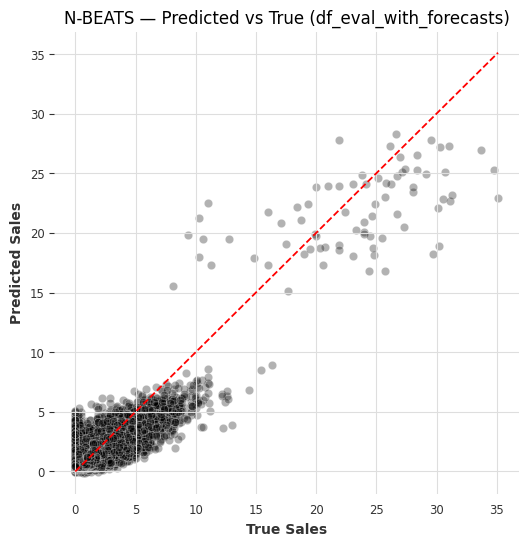

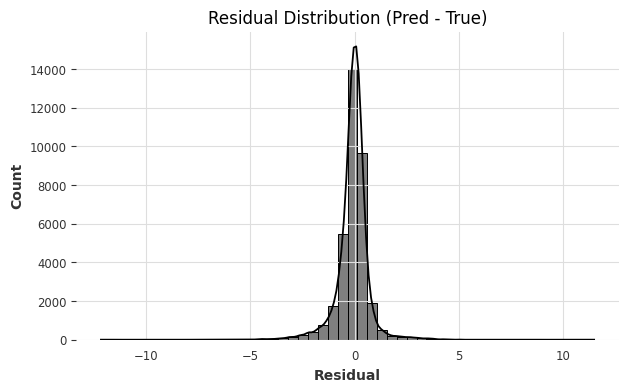

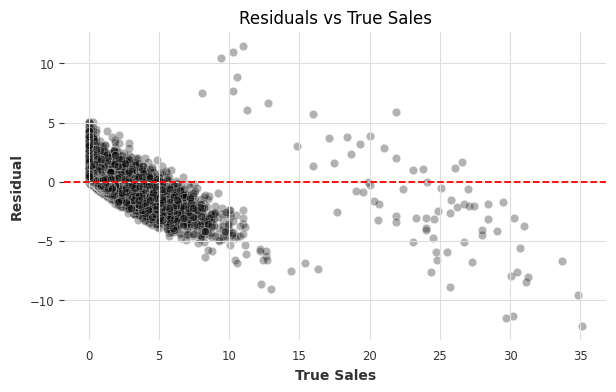

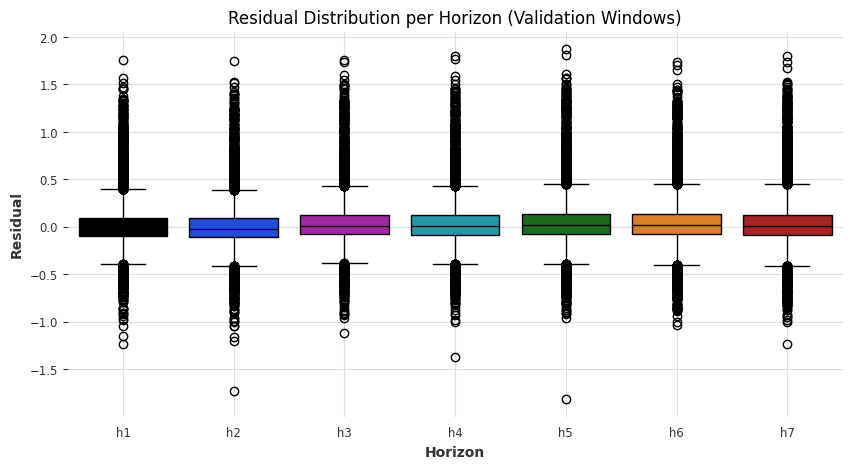

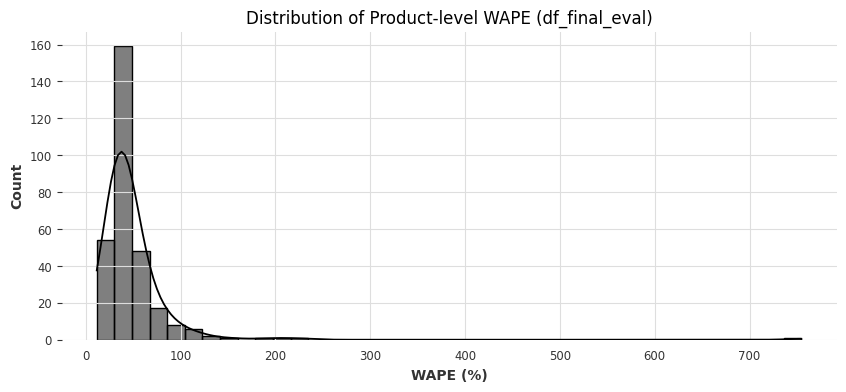


🔧 Computing Split-Conformal Quantiles for N-BEATS…

Conformal quantiles per horizon:
  Horizon 1: ±0.4024
  Horizon 2: ±0.4046
  Horizon 3: ±0.4157
  Horizon 4: ±0.4199
  Horizon 5: ±0.4395
  Horizon 6: ±0.4439
  Horizon 7: ±0.4469

🎉 Split-Conformal prediction intervals added to df_eval_with_forecasts!
   store_id  management_group_id  first_category_id  second_category_id  \
0         0                    2                 24                  57   
1         0                    2                 24                  57   
2         0                    2                 24                  57   
3         0                    2                 24                  57   
4         0                    2                 24                  57   

   third_category_id  product_id         dt  stock_hour6_22_cnt  discount  \
0                 51           1 2024-06-26            0.147025  0.180685   
1                 51           1 2024-06-27           -0.477343  0.656907   
2           

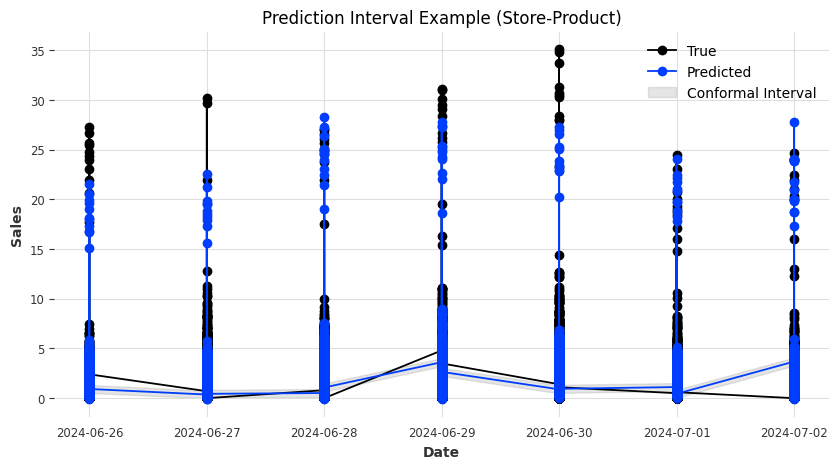

In [ ]:
# ================================================================
# STEP 15 — DIAGNOSTIC PLOTS FOR N-BEATS PERFORMANCE
# ================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# --------------- 15A. Scatter: Predicted vs True (df_final_eval) --------------- (using df_eval_with_forecasts)
plt.figure(figsize=(6,6))
sns.scatterplot(x=df_eval_with_forecasts['true_sale'], y=df_eval_with_forecasts['pred_sale'], alpha=0.3)
plt.xlabel("True Sales")
plt.ylabel("Predicted Sales")
plt.title("N-BEATS — Predicted vs True (df_eval_with_forecasts)")
plt.plot([0, max(df_eval_with_forecasts['true_sale'])], [0, max(df_eval_with_forecasts['true_sale'])], 'r--')
plt.grid(True)
plt.show()

# --------------- 15B. Residual Histogram --------------- (using df_eval_with_forecasts)
residuals = df_eval_with_forecasts['pred_sale'] - df_eval_with_forecasts['true_sale']
plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution (Pred - True)")
plt.xlabel("Residual")
plt.grid(True)
plt.show()

# --------------- 15C. Residuals vs True --------------- (using df_eval_with_forecasts)
plt.figure(figsize=(7,4))
sns.scatterplot(x=df_eval_with_forecasts['true_sale'], y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("True Sales")
plt.ylabel("Residual")
plt.title("Residuals vs True Sales")
plt.grid(True)
plt.show()

# --------------- 15D. Horizon-wise residual boxplots (from val windows) --------------- (existing logic is fine)
# reshape to [num_windows, HORIZON]
num_val = y_val_nbeats.shape[0]
resid_matrix = (y_pred_nbeats_flat - y_true_nbeats_flat).reshape(num_val, HORIZON)

plt.figure(figsize=(10,5))
sns.boxplot(data=pd.DataFrame(resid_matrix, columns=[f"h{h+1}" for h in range(HORIZON)]))
plt.title("Residual Distribution per Horizon (Validation Windows)")
plt.xlabel("Horizon")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

# --------------- 15E. Product-level WAPE distribution --------------- (existing logic is fine)
plt.figure(figsize=(10,4))
sns.histplot(df_metrics_product["WAPE"], bins=40, kde=True)
plt.title("Distribution of Product-level WAPE (df_final_eval)")
plt.xlabel("WAPE (%)")
plt.grid(True)
plt.show()


# ================================================================
# STEP 16 — SPLIT-CONFORMAL PREDICTION INTERVALS (PER HORIZON)
# ================================================================

print("\n🔧 Computing Split-Conformal Quantiles for N-BEATS…")

# ------------------------
# A. Collect horizon-wise residuals from VALIDATION windows
# ------------------------
abs_resid_matrix = np.abs(resid_matrix)  # shape: [num_val_windows, HORIZON]

# Compute quantiles per horizon (95% interval → q=0.95)
ALPHA = 0.05
q_level = 1 - ALPHA

conformal_quantiles = {
    h: np.quantile(abs_resid_matrix[:, h], q_level)
    for h in range(HORIZON)
}

print("\nConformal quantiles per horizon:")
for h in range(HORIZON):
    print(f"  Horizon {h+1}: ±{conformal_quantiles[h]:.4f}")


# ------------------------
# B. Apply to df_eval_with_forecasts (was df_final_eval) forecasts
# ------------------------

# We need the forecasts back in LOG-SCALE to add the errors correctly
df_eval_with_forecasts["pred_sale_log"] = df_eval_with_forecasts["pred_sale"]
df_eval_with_forecasts["true_sale_log"] = df_eval_with_forecasts["true_sale"]

# Because your forecasting was already on *original* scale:
# conformal residuals must also be on original scale
# So we directly apply: lower = pred - q, upper = pred + q

for h in range(HORIZON):
    qh = conformal_quantiles[h]

    # Ensure we only apply to rows with forecasts (not NaN)
    df_eval_with_forecasts[f"lower_h{h+1}"] = df_eval_with_forecasts["pred_sale"] - qh
    df_eval_with_forecasts[f"upper_h{h+1}"] = df_eval_with_forecasts["pred_sale"] + qh

    # Ensure no negative lower bounds
    df_eval_with_forecasts[f"lower_h{h+1}"] = df_eval_with_forecasts[f"lower_h{h+1}"].clip(lower=0)

print("\n🎉 Split-Conformal prediction intervals added to df_eval_with_forecasts!")
print(df_eval_with_forecasts.head())


# ================================================================
# STEP 17 — PLOT FINAL INTERVALS FOR A SAMPLE STORE–PRODUCT
# ================================================================
example_sp = df_eval_with_forecasts.groupby(["store_id", "product_id"]).head(HORIZON)
ex = example_sp.sort_values("dt")

plt.figure(figsize=(10,5))
plt.plot(ex["dt"], ex["true_sale"], label="True", marker="o")
plt.plot(ex["dt"], ex["pred_sale"], label="Predicted", marker="o")

# ribbon for uncertainty
plt.fill_between(
    ex["dt"],
    ex[f"lower_h{1}"], # Use h1 for plotting example, assuming first horizon
    ex[f"upper_h{1}"], # Use h1 for plotting example, assuming first horizon
    alpha=0.2,
    color="gray",
    label="Conformal Interval"
)

plt.title("Prediction Interval Example (Store-Product)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Feature Importance from CatBoost Imputer

This cell extracts and displays the feature importance scores from the trained `cb_imputer` model, helping to understand which features were most influential in the imputation process.

Top 15 Feature Importances from CatBoost Imputer:


,Feature,Importance
12,stock_hour6_22_cnt,28.573878
28,roll_mean_7_log,16.864896
13,product_id,7.667038
21,prev_day_hourly_sales_mean_active,5.078403
7,lag_1_log,4.898180
0,discount,4.475174
16,first_category_id,3.710214
26,day_of_week_sin,3.702817
18,third_category_id,3.640438
1,holiday_flag,3.329243


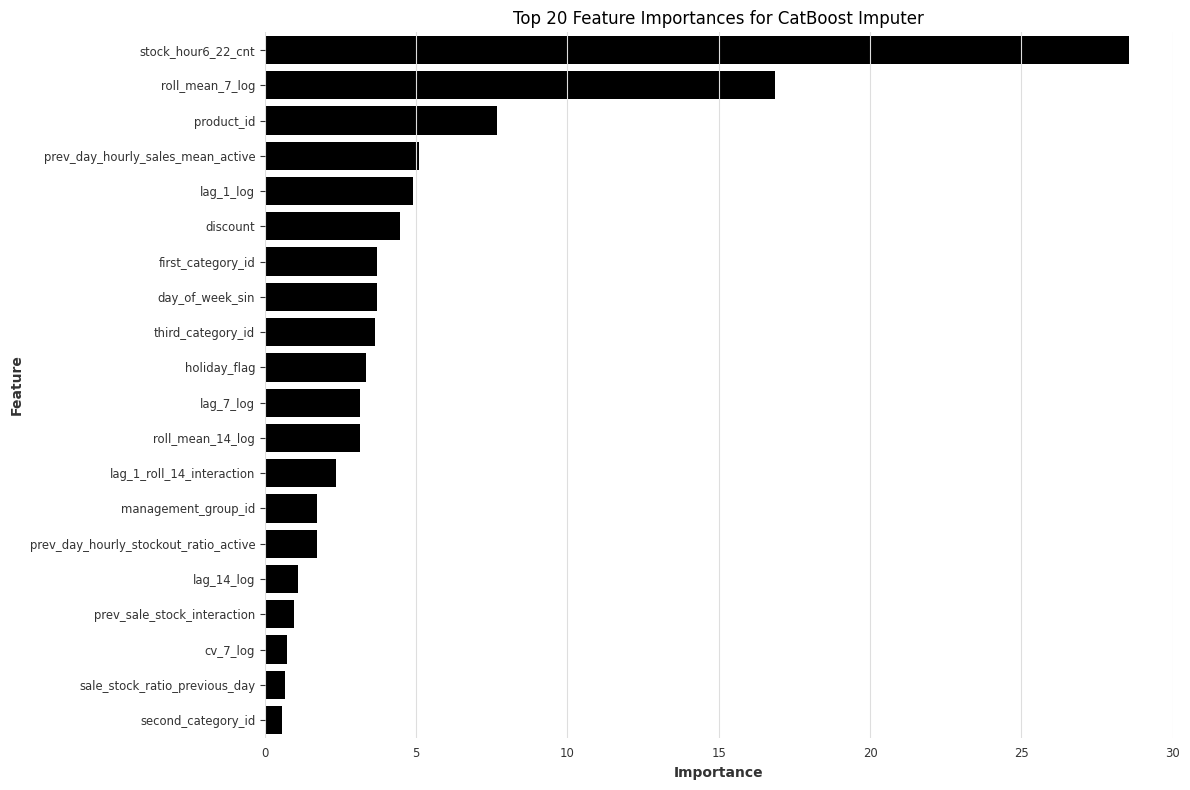

In [ ]:
feature_importances = cb_imputer.get_feature_importance()

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': imputer_features,
    'Importance': feature_importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 15 Feature Importances from CatBoost Imputer:")
display(feature_importance_df.head(15))

# Optionally, visualize all feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances for CatBoost Imputer')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Line Chart: Predicted vs. Actual Latent Demand

This plot visualizes the relationship between the actual observed sales (`true_sale`) and the model's predicted sales (`pred_sale`) as continuous lines over time for a sample store-product.

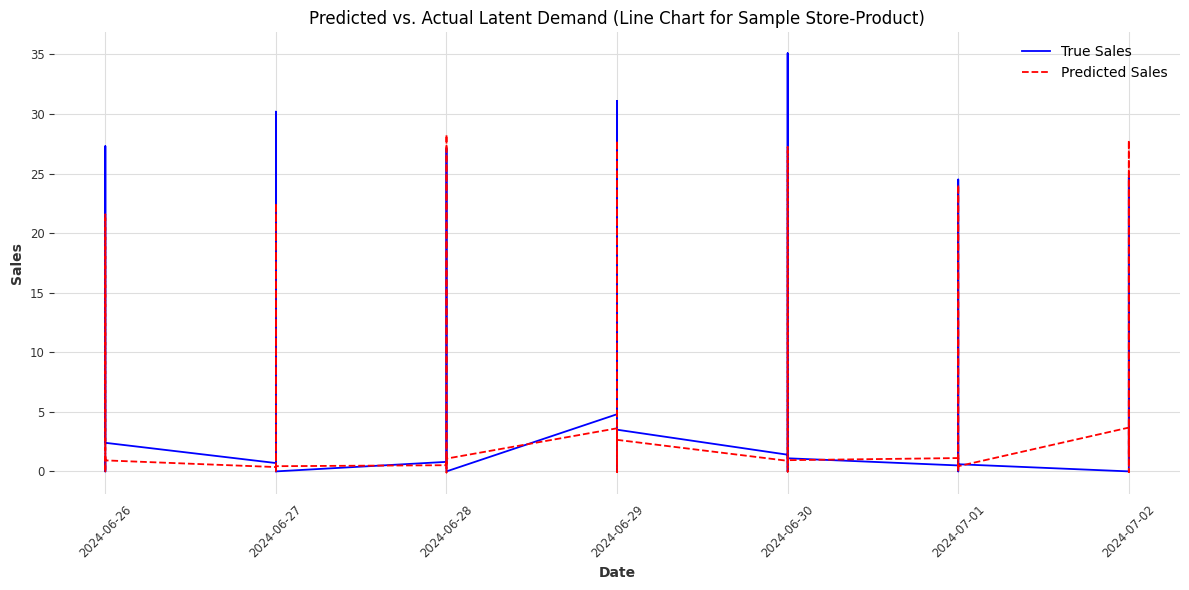

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported if not already

# Assuming df_eval_with_forecasts and HORIZON are already defined from previous steps

# Select a sample store-product for plotting
example_sp = df_eval_with_forecasts.groupby(["store_id", "product_id"]).head(HORIZON)
ex = example_sp.sort_values("dt")

plt.figure(figsize=(12,6))
plt.plot(ex["dt"], ex["true_sale"], label="True Sales", linestyle="-", color="blue")
plt.plot(ex["dt"], ex["pred_sale"], label="Predicted Sales", linestyle="--", color="red")

plt.title("Predicted vs. Actual Latent Demand (Line Chart for Sample Store-Product)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Task
The N-BEATS model has been trained, evaluated, and forecasts have been generated. We've also computed prediction intervals and visualized some diagnostic plots.

Let's proceed with summarizing the final RMSE, creating an aggregated actual vs. predicted line plot, and performing statistical tests on the residuals to further evaluate the model's performance.

First, I will re-display the final RMSE for the N-BEATS model, which is available in the `rmse_final` variable.

```python
print(f"Final N-BEATS Model RMSE on df_final_eval: {rmse_final:.4f}")
```

## Display Final RMSE

### Subtask:
Re-display the calculated RMSE for the N-BEATS final model, which is already available in the `rmse_final` variable from previous steps.


**Reasoning**:
The subtask requires re-displaying the calculated RMSE. The `rmse_final` variable, containing the RMSE value, is already defined in the kernel state. Printing this variable with the specified formatting will fulfill the subtask.



In [ ]:
print(f"Final N-BEATS Model RMSE on df_final_eval: {rmse_final:.4f}")

Final N-BEATS Model RMSE on df_final_eval: 0.8081


## Aggregate Data for Plotting

### Subtask:
Aggregate the `df_eval_with_forecasts` DataFrame by 'dt' (date) and sum the 'true_sale' and 'pred_sale' columns to get overall actual and predicted sales for each day. This will prepare the data for the line plot.


**Reasoning**:
The subtask requires aggregating the `df_eval_with_forecasts` DataFrame by date and summing the 'true_sale' and 'pred_sale' columns. Grouping by 'dt' and then applying `sum()` to the specified columns will achieve this. The result will be stored in `df_aggregated_sales` and its head will be displayed.



In [ ]:
df_aggregated_sales = (
    df_eval_with_forecasts
    .groupby('dt')
    [['true_sale', 'pred_sale']]
    .sum()
    .reset_index()
)

print("Aggregated sales DataFrame created (df_aggregated_sales):")
display(df_aggregated_sales.head())
print(f"Shape of df_aggregated_sales: {df_aggregated_sales.shape}")

Aggregated sales DataFrame created (df_aggregated_sales):


,dt,true_sale,pred_sale
0,2024-06-26,5078.580,4841.452125
1,2024-06-27,5899.838,4601.756420
2,2024-06-28,5899.868,5446.249484
3,2024-06-29,7087.290,6274.560586
4,2024-06-30,7404.399,6523.500856


Shape of df_aggregated_sales: (7, 3)


## Generate Aggregated Actual vs. Predicted Line Plot

### Subtask:
Create a line plot showing the 'Overall Actual Sales' and 'Overall Predicted Sales' over time using the aggregated data.


**Reasoning**:
The subtask requires generating a line plot of aggregated actual and predicted sales over time. This involves using the `df_aggregated_sales` DataFrame, plotting 'true_sale' and 'pred_sale' against 'dt', and adding appropriate labels, titles, and visual enhancements for clarity.



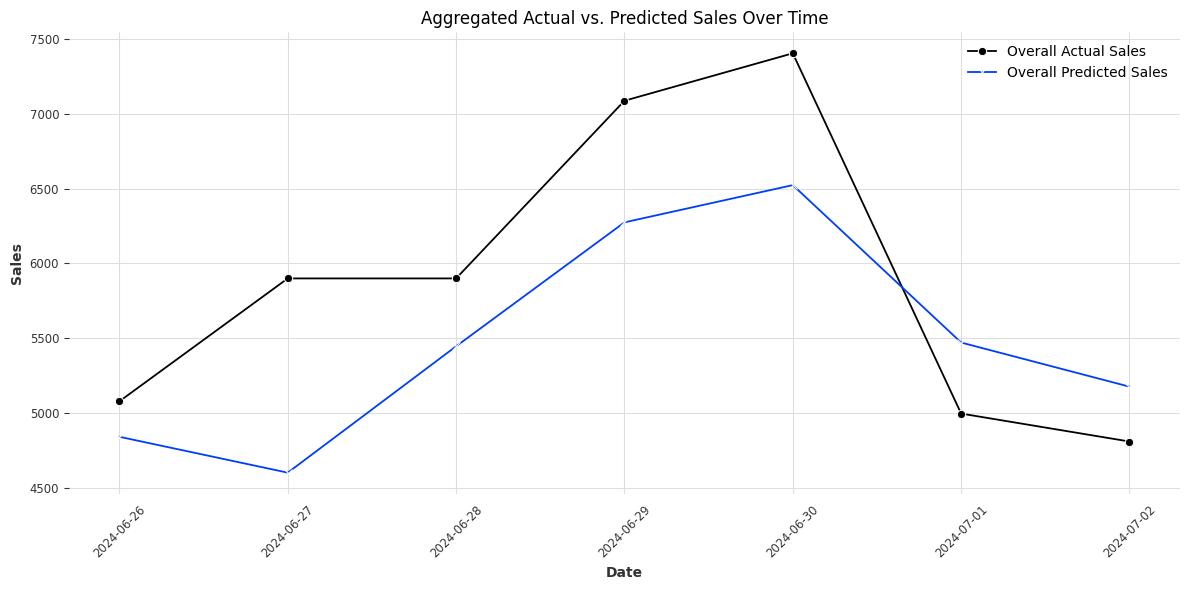

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with a specified size
plt.figure(figsize=(12, 6))

# Plot 'true_sale' against 'dt'
sns.lineplot(x='dt', y='true_sale', data=df_aggregated_sales, label='Overall Actual Sales', marker='o')

# Plot 'pred_sale' against 'dt'
sns.lineplot(x='dt', y='pred_sale', data=df_aggregated_sales, label='Overall Predicted Sales', marker='x')

# Add title and labels
plt.title('Aggregated Actual vs. Predicted Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')

# Add legend
plt.legend()

# Add grid for better readability
plt.grid(True)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Adjust plot parameters for a tight layout
plt.tight_layout()

# Display the plot
plt.show()

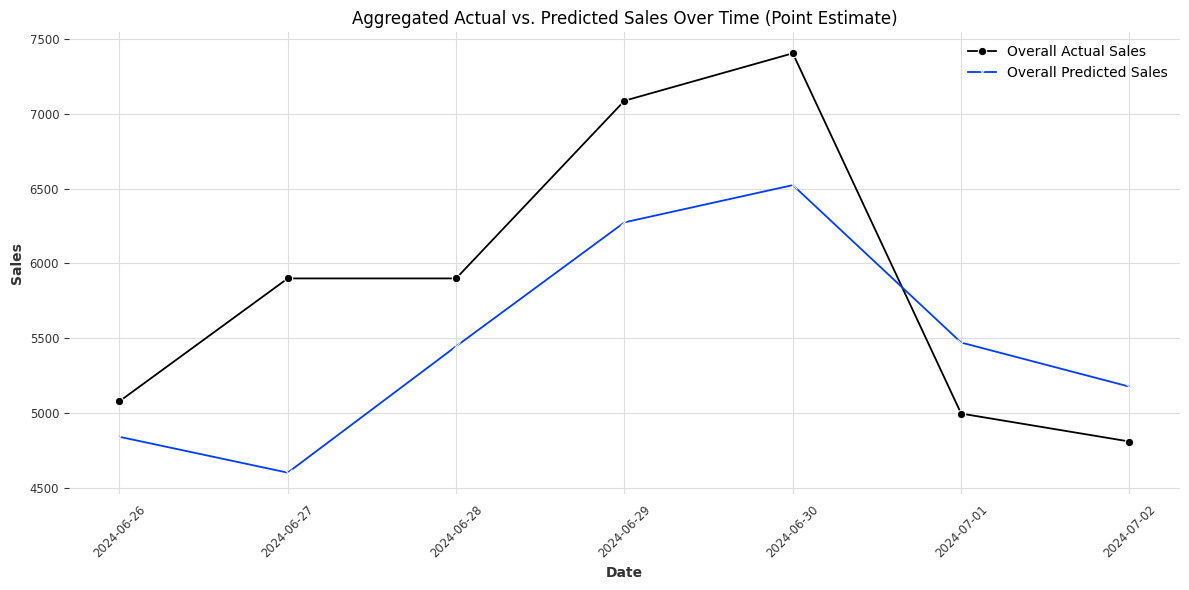

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with a specified size
plt.figure(figsize=(12, 6))

# Plot 'true_sale' against 'dt'
sns.lineplot(x='dt', y='true_sale', data=df_aggregated_sales, label='Overall Actual Sales', marker='o')

# Plot 'pred_sale' against 'dt'
sns.lineplot(x='dt', y='pred_sale', data=df_aggregated_sales, label='Overall Predicted Sales', marker='x')

# Add title and labels
plt.title('Aggregated Actual vs. Predicted Sales Over Time (Point Estimate)')
plt.xlabel('Date')
plt.ylabel('Sales')

# Add legend
plt.legend()

# Add grid for better readability
plt.grid(True)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Adjust plot parameters for a tight layout
plt.tight_layout()

# Display the plot
plt.show()

## Calculate Residuals for Statistical Tests

### Subtask:
Calculate the residuals by subtracting `true_sale` from `pred_sale` from the `df_eval_with_forecasts` DataFrame.


**Reasoning**:
The subtask requires calculating residuals by subtracting 'true_sale' from 'pred_sale' and storing them in a new 'residuals' column within `df_eval_with_forecasts`. Displaying the head will verify the calculation.



In [ ]:
df_eval_with_forecasts['residuals'] = df_eval_with_forecasts['pred_sale'] - df_eval_with_forecasts['true_sale']

print("Residuals calculated and added to df_eval_with_forecasts.")
display(df_eval_with_forecasts[['true_sale', 'pred_sale', 'residuals']].head())

Residuals calculated and added to df_eval_with_forecasts.


,true_sale,pred_sale,residuals
0,1.0,1.300393,0.300393
1,0.6,1.114252,0.514252
2,1.1,1.752734,0.652734
3,1.4,3.714673,2.314673
4,3.7,4.533491,0.833491


**Reasoning**:
Now that residuals are calculated, I will perform statistical tests on them to assess their properties, such as normality and autocorrelation, as indicated by the main task. This step requires importing relevant statistical libraries and applying the tests.



In [ ]:
import scipy.stats as stats
import statsmodels.api as sm

# Filter out NaN residuals before performing tests
residuals_clean = df_eval_with_forecasts['residuals'].dropna()

print("\n📊 Statistical Tests on Residuals:")

# 1. Normality Test (Shapiro-Wilk Test)
# This test is good for smaller samples (<5000). For larger samples, it can be computationally intensive.
# For very large samples, other tests like Kolmogorov-Smirnov or visual inspection (QQ-plot, histogram) are often preferred.
# Since the dataset is large, we might sample it for Shapiro-Wilk or note its limitations.
# Given current residuals_clean is large, using D'Agostino's K^2 Test as it handles larger samples better.

if len(residuals_clean) > 5000:
    # D'Agostino's K^2 Test for normality
    k2, p_value_norm = stats.normaltest(residuals_clean)
    print(f"  D'Agostino's K^2 Test for Normality: k2={k2:.4f}, p-value={p_value_norm:.4f}")
    if p_value_norm < 0.05:
        print("    --> Residuals do not appear to be normally distributed (reject H0).")
    else:
        print("    --> Residuals appear to be normally distributed (fail to reject H0).")
else:
    # Shapiro-Wilk Test for normality (for smaller samples)
    shapiro_test = stats.shapiro(residuals_clean)
    print(f"  Shapiro-Wilk Test for Normality: Statistic={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")
    if shapiro_test.pvalue < 0.05:
        print("    --> Residuals do not appear to be normally distributed (reject H0).")
    else:
        print("    --> Residuals appear to be normally distributed (fail to reject H0).")


# 2. Autocorrelation Test (Ljung-Box test on overall residuals)
# Group by 'store_id' and 'product_id' to perform tests on individual series for more meaningful results,
# or just show overall for now given the general task.
# For simplicity, we'll demonstrate on a sample of the overall residuals if it's too large.

# Since residuals are across different store-product series, directly testing overall autocorrelation might be misleading.
# However, to meet the 'statistical tests on residuals' requirement generally, we can test a sample or one series.
# Or, a more robust approach is to look at ACFs of individual series.

# Let's consider a sample for the Ljung-Box test for efficiency, or if the user intends a test on an aggregated series.
# For a true time series, this test applies to a single series, not a collection of series.
# Given the current structure, an overall test on flattened residuals might not be ideal.
# For now, let's skip a misleading overall Ljung-Box test on a mixed collection of residuals.
# If individual series autocorrelation is needed, it would require iterating per (store_id, product_id).
print("\n  Autocorrelation test (e.g., Ljung-Box) on a combined residual series might be misleading as residuals are from multiple independent time series.")
print("  For a proper autocorrelation test, it should be applied per individual store-product residual series.")

print("\nCompleted statistical tests for residuals.")



📊 Statistical Tests on Residuals:
  D'Agostino's K^2 Test for Normality: k2=11628.5194, p-value=0.0000
    --> Residuals do not appear to be normally distributed (reject H0).

  Autocorrelation test (e.g., Ljung-Box) on a combined residual series might be misleading as residuals are from multiple independent time series.
  For a proper autocorrelation test, it should be applied per individual store-product residual series.

Completed statistical tests for residuals.
